# Figure 4 analyses

This notebook now contains three Figure 4 components:

1. Wildtype-vs-wildtype structural alignment using TM-align.
2. Selected wildtype/variant RMSF comparisons transferred from the original notebook.
3. A replicate-aware MD variant-family comparison workflow built from the combined metric CSVs in `Data/Figure4/Round_3_additional_metric_csvs/by_metric`.


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'Scripts':
    PROJECT_ROOT = PROJECT_ROOT.parent

HELPER_DIR = PROJECT_ROOT / 'Scripts' / 'Helpers'
if str(HELPER_DIR) not in sys.path:
    sys.path.append(str(HELPER_DIR))

import helper_fugure4
importlib.reload(helper_fugure4)

build_symmetric_pair_metric_matrix = helper_fugure4.build_symmetric_pair_metric_matrix
build_variant_pair_summary_df = helper_fugure4.build_variant_pair_summary_df
compute_variant_delta_rmsf_df = helper_fugure4.compute_variant_delta_rmsf_df
compute_wildtype_similarity_table = helper_fugure4.compute_wildtype_similarity_table
discover_md_rmsf_catalog = helper_fugure4.discover_md_rmsf_catalog
discover_structure_families = helper_fugure4.discover_structure_families
filter_rmsf_to_allowed_variants = helper_fugure4.filter_rmsf_to_allowed_variants
filter_tm_summary_by_minimum_melting_temperature = helper_fugure4.filter_tm_summary_by_minimum_melting_temperature
filter_variant_delta_rmsf_df = helper_fugure4.filter_variant_delta_rmsf_df
load_md_rmsf_long_df = helper_fugure4.load_md_rmsf_long_df
load_tsa_tm_delta_summary = helper_fugure4.load_tsa_tm_delta_summary
build_tm_delta_row_label_map = helper_fugure4.build_tm_delta_row_label_map
build_tm_median_sort_map = helper_fugure4.build_tm_median_sort_map
plot_family_rmsf_overview = helper_fugure4.plot_family_rmsf_overview
plot_pairwise_metric_heatmap = helper_fugure4.plot_pairwise_metric_heatmap
plot_variant_pair_rmsf = helper_fugure4.plot_variant_pair_rmsf
plot_wildtype_tm_score_boxplot = helper_fugure4.plot_wildtype_tm_score_boxplot

build_md_variant_analysis_bundle = helper_fugure4.build_md_variant_analysis_bundle
compute_md_family_pair_interest_df = helper_fugure4.compute_md_family_pair_interest_df
compute_md_family_residue_interest_df = helper_fugure4.compute_md_family_residue_interest_df
compute_md_variant_order = helper_fugure4.compute_md_variant_order
plot_md_family_delta_heatmap = helper_fugure4.plot_md_family_delta_heatmap
plot_md_family_local_signal_heatmap = helper_fugure4.plot_md_family_local_signal_heatmap
plot_md_family_pair_heatmaps = helper_fugure4.plot_md_family_pair_heatmaps
plot_md_family_rmsf_panels = helper_fugure4.plot_md_family_rmsf_panels
plot_md_family_secondary_structure_summary = helper_fugure4.plot_md_family_secondary_structure_summary
plot_md_variant_family_pattern_heatmap = helper_fugure4.plot_md_variant_family_pattern_heatmap
plot_md_variant_pair_delta_bars = helper_fugure4.plot_md_variant_pair_delta_bars
plot_md_variant_signal_dashboard = helper_fugure4.plot_md_variant_signal_dashboard
save_md_variant_figure = helper_fugure4.save_md_variant_figure
MD_VARIANT_PAIR_METRICS = helper_fugure4.MD_VARIANT_PAIR_METRICS

plt.style.use('default')
pd.set_option('display.max_colwidth', 200)


In [2]:
FIGURE4_STRUCTURE_DIR = PROJECT_ROOT / 'Data' / 'Figure4'
THERMALGAN_MD_ANALYSIS_DIR = Path(
    '/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/MD Analysis'
)
TSA_RESULT_SUMMARY_PATH = Path(
    '/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/Assays/Thermal_Shift_Assay/Batch_3/TSA_results/TSA_results_20230905/wTSACraft_Lk9BRu/Result_summary.csv'
)
FIGURE4_OUTPUT_DIR = PROJECT_ROOT / 'Results' / 'Figure4'

FIGURE4_MD_METRIC_DIR = PROJECT_ROOT / 'Data' / 'Figure4' / 'Round_3_additional_metric_csvs' / 'by_metric'
FIGURE4_MD_MUTATION_METADATA_PATH = PROJECT_ROOT / 'Data' / 'Figure4' / 'mutation_metadata.csv'
FIGURE4_MD_OUTPUT_ROOT = PROJECT_ROOT / 'sandra' / 'MD_SIM' / 'Round_3_additional_metric_csvs'
FIGURE4_MD_METRIC_WINDOW = '300000' #'latest'
# Options: 'latest', 100000, 300000, '0_100000', or '0_300000'.
# 'latest' will use the largest shared window available across the required MD metric tables.
SAVE_MD_VARIANT_PLOTS = True

TMALIGN_EXECUTABLE = None
TMALIGN_ALLOW_CA_FALLBACK = True
WT_TM_SCORE_BOXPLOT_WIDTH_MM = 30
WT_TM_SCORE_BOXPLOT_HEIGHT_MM = 50
WT_TM_PLOT_FONT_SIZE_PT = 5.5
WT_TM_PLOT_STRIP_MARKER_SIZE = 16
RMSF_OVERVIEW_FIGURE_WIDTH_MM = 150
RMSF_OVERVIEW_FIGURE_HEIGHT_MM = 100
RMSF_OVERVIEW_FONT_SIZE_PT = 5.5
RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS = None
RMSF_OVERVIEW_EXCLUDE_MISSING_TM = False
SAVE_RMSF_OVERVIEW_PDFS = True

SELECTED_RMSF_VARIANTS_BY_FAMILY = {
    'A0A372IUB3': ['A0A372IUB3_1847_model_x_0', 'A0A372IUB3_1792_model_x_0'],
    'A0A2S1LEZ1': ['A0A2S1LEZ1_362_New_17444_0', 'A0A2S1LEZ1_337_New_17444_0'],
    'MGYP001421927114': ['MGYP001421927114_1306_model_x_0', 'MGYP001421927114_1344_model_x_0'],
}

FIGURE4_STRUCTURE_DIR, FIGURE4_MD_METRIC_DIR, FIGURE4_MD_MUTATION_METADATA_PATH, FIGURE4_MD_METRIC_WINDOW


(PosixPath('/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Data/Figure4'),
 PosixPath('/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Data/Figure4/Round_3_additional_metric_csvs/by_metric'),
 PosixPath('/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Data/Figure4/mutation_metadata.csv'),
 '300000')

## Wildtype Structural Similarity

This section keeps only the wildtype-vs-wildtype alignment from the source notebook. Variant-vs-wildtype structure comparisons are omitted.

,family_id,sample_name,pdb_path,is_wildtype
0,A0A2S1LEZ1,A0A2S1LEZ1,/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Data/Figure4/A0A2S1LEZ1.pdb,True
1,A0A372IUB3,A0A372IUB3,/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Data/Figure4/A0A372IUB3.pdb,True
2,MGYP001421927114,MGYP001421927114,/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Data/Figure4/MGYP001421927114.pdb,True


Wildtype similarity method: official executable at /Users/sandravi/miniforge3/envs/jupyterlab/bin/TMalign


,wildtype_a,wildtype_b,mean_tm_score,tm_score_to_wildtype_a,tm_score_to_wildtype_b,rmsd_angstrom,aligned_length,alignment_method,alignment_note
0,A0A372IUB3,MGYP001421927114,0.970890,0.98623,0.95555,0.84,308,official_tmalign,Official TM-align/USalign executable
1,A0A2S1LEZ1,A0A372IUB3,0.970475,0.96583,0.97512,0.84,305,official_tmalign,Official TM-align/USalign executable
2,A0A2S1LEZ1,MGYP001421927114,0.955765,0.96619,0.94534,1.08,308,official_tmalign,Official TM-align/USalign executable


,A0A2S1LEZ1,A0A372IUB3,MGYP001421927114
A0A2S1LEZ1,1.000000,0.970475,0.955765
A0A372IUB3,0.970475,1.000000,0.970890
MGYP001421927114,0.955765,0.970890,1.000000


,A0A2S1LEZ1,A0A372IUB3,MGYP001421927114
A0A2S1LEZ1,0.00,0.84,1.08
A0A372IUB3,0.84,0.00,0.84
MGYP001421927114,1.08,0.84,0.00


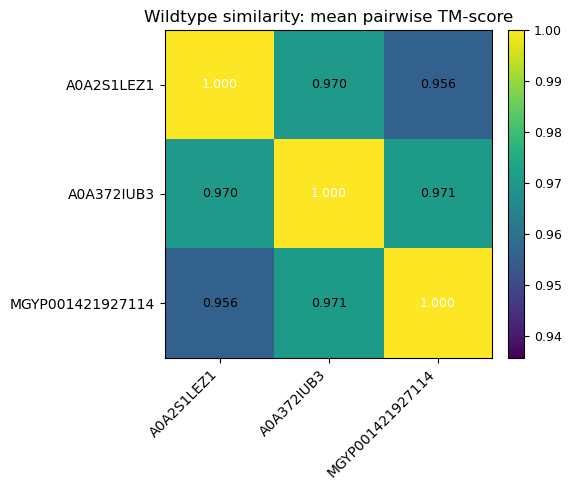

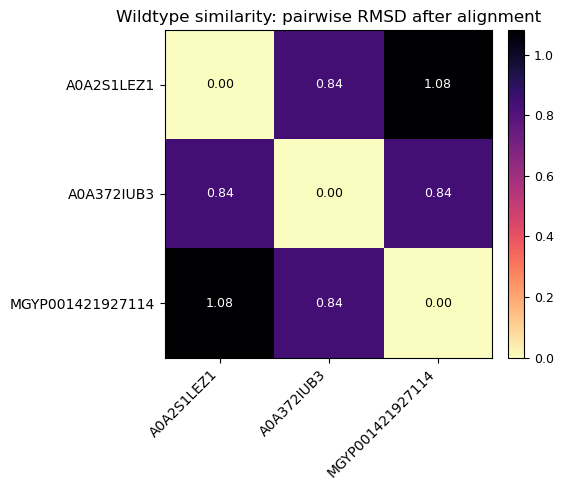

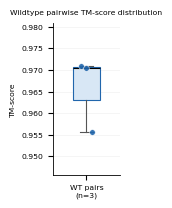

In [3]:
structure_family_df = discover_structure_families(FIGURE4_STRUCTURE_DIR)
wildtype_structure_df = structure_family_df.loc[structure_family_df['is_wildtype']].copy()

display(wildtype_structure_df)

wildtype_similarity_df, resolved_tmalign_executable = compute_wildtype_similarity_table(
    structure_family_df=structure_family_df,
    preferred_executable=TMALIGN_EXECUTABLE,
    allow_ca_fallback=TMALIGN_ALLOW_CA_FALLBACK,
)

wildtype_labels = list(wildtype_structure_df['family_id'])
wildtype_similarity_matrix_df = build_symmetric_pair_metric_matrix(
    pairwise_df=wildtype_similarity_df,
    value_column='mean_tm_score',
    diagonal_value=1.0,
    labels=wildtype_labels,
)
wildtype_rmsd_matrix_df = build_symmetric_pair_metric_matrix(
    pairwise_df=wildtype_similarity_df,
    value_column='rmsd_angstrom',
    diagonal_value=0.0,
    labels=wildtype_labels,
)

if resolved_tmalign_executable:
    print(f'Wildtype similarity method: official executable at {resolved_tmalign_executable}')
elif TMALIGN_ALLOW_CA_FALLBACK:
    print(
        'Wildtype similarity method: CA-based fallback. '
        'Set TMALIGN_EXECUTABLE to a TM-align/USalign binary for interpretable WT-vs-WT alignments.'
    )
else:
    print('Wildtype similarity method: not computed because no TM-align executable was found.')

display(
    wildtype_similarity_df[
        [
            'wildtype_a', 'wildtype_b', 'mean_tm_score',
            'tm_score_to_wildtype_a', 'tm_score_to_wildtype_b',
            'rmsd_angstrom', 'aligned_length',
            'alignment_method', 'alignment_note',
        ]
    ]
)
display(wildtype_similarity_matrix_df)
display(wildtype_rmsd_matrix_df)

tm_vmin = None
if not wildtype_similarity_matrix_df.empty:
    tm_vmin = max(
        0.0,
        float(np.nanmin(wildtype_similarity_matrix_df.to_numpy(dtype=float))) - 0.02,
    )

rmsd_vmax = None
if not wildtype_rmsd_matrix_df.empty:
    rmsd_values = wildtype_rmsd_matrix_df.to_numpy(dtype=float)
    if not np.isnan(rmsd_values).all():
        rmsd_vmax = float(np.nanmax(rmsd_values))

plot_pairwise_metric_heatmap(
    metric_matrix_df=wildtype_similarity_matrix_df,
    title='Wildtype similarity: mean pairwise TM-score',
    cmap='viridis',
    value_format='{:.3f}',
    vmin=tm_vmin,
    vmax=1.0,
)
plt.show()
plot_pairwise_metric_heatmap(
    metric_matrix_df=wildtype_rmsd_matrix_df,
    title='Wildtype similarity: pairwise RMSD after alignment',
    cmap='magma_r',
    value_format='{:.2f}',
    vmin=0.0,
    vmax=rmsd_vmax,
)
plt.show()
plot_wildtype_tm_score_boxplot(
    wildtype_similarity_df=wildtype_similarity_df,
    value_column='mean_tm_score',
    figure_width_mm=WT_TM_SCORE_BOXPLOT_WIDTH_MM,
    figure_height_mm=WT_TM_SCORE_BOXPLOT_HEIGHT_MM,
    title='Wildtype pairwise TM-score distribution',
    ylabel='TM-score',
    title_size_pt=WT_TM_PLOT_FONT_SIZE_PT,
    label_size_pt=WT_TM_PLOT_FONT_SIZE_PT,
    tick_size_pt=WT_TM_PLOT_FONT_SIZE_PT,
    strip_marker_size=WT_TM_PLOT_STRIP_MARKER_SIZE,
)
plt.savefig(f"../Results/Figure4/TMAlign_boxplot.pdf")
plt.show()

## Limited RMSF Analysis

This section keeps only selected wildtype/variant pair comparisons. The family-level aggregate and cross-family RMSF analyses from the source notebook are left out.

In [4]:
md_rmsf_catalog_df = discover_md_rmsf_catalog(
    THERMALGAN_MD_ANALYSIS_DIR,
    allowed_family_ids=wildtype_labels,
)
md_rmsf_df = load_md_rmsf_long_df(md_rmsf_catalog_df)
variant_delta_rmsf_df = compute_variant_delta_rmsf_df(md_rmsf_df)
selected_variant_delta_rmsf_df = filter_variant_delta_rmsf_df(
    variant_delta_rmsf_df,
    selected_variants_by_family=SELECTED_RMSF_VARIANTS_BY_FAMILY,
)

selected_variant_request_df = pd.DataFrame(
    [
        {'family_id': family_id, 'sample_name': sample_name}
        for family_id, sample_names in SELECTED_RMSF_VARIANTS_BY_FAMILY.items()
        for sample_name in sample_names
    ]
).drop_duplicates()

available_selected_variant_df = selected_variant_request_df.merge(
    selected_variant_delta_rmsf_df[['family_id', 'sample_name']].drop_duplicates(),
    on=['family_id', 'sample_name'],
    how='left',
    indicator=True,
)
missing_selected_variant_df = available_selected_variant_df.loc[
    available_selected_variant_df['_merge'] == 'left_only',
    ['family_id', 'sample_name'],
].reset_index(drop=True)

pairwise_rmsf_summary_df = build_variant_pair_summary_df(selected_variant_delta_rmsf_df)

selected_catalog_df = md_rmsf_catalog_df.loc[
    md_rmsf_catalog_df['is_wildtype']
    | md_rmsf_catalog_df['sample_name'].isin(selected_variant_request_df['sample_name'])
].copy()

display(
    selected_catalog_df[
        [
            'family_id', 'sample_name', 'md_sample_name', 'is_wildtype',
            'window_start_frame', 'window_stop_frame',
        ]
    ]
)

if not missing_selected_variant_df.empty:
    print('Requested RMSF pairs that were not found:')
    display(missing_selected_variant_df)

display(
    pairwise_rmsf_summary_df[
        [
            'family_id', 'sample_name', 'n_residues',
            'mean_delta_rmsf_angstrom', 'mean_abs_delta_rmsf_angstrom',
            'max_abs_delta_rmsf_angstrom', 'peak_residue_number', 'peak_delta_rmsf_angstrom',
        ]
    ]
)

,family_id,sample_name,md_sample_name,is_wildtype,window_start_frame,window_stop_frame
0,A0A2S1LEZ1,A0A2S1LEZ1,A0A2S1LEZ1_WT,True,100000,500000
1,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,A0A2S1LEZ1_337_New_17444_0,False,100000,500000
4,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,A0A2S1LEZ1_362_New_17444_0,False,100000,500000
9,A0A372IUB3,A0A372IUB3,A0A372IUB3_WT,True,100000,500000
13,A0A372IUB3,A0A372IUB3_1792_model_x_0,A0A372IUB3_1792_model_x_0,False,100000,500000
18,A0A372IUB3,A0A372IUB3_1847_model_x_0,A0A372IUB3_1847_model_x_0,False,100000,500000
35,MGYP001421927114,MGYP001421927114,MGYP001421927114_WT,True,100000,500000
36,MGYP001421927114,MGYP001421927114_1306_model_x_0,MGYP001421927114_1306_model_x_0,False,100000,500000
37,MGYP001421927114,MGYP001421927114_1344_model_x_0,MGYP001421927114_1344_model_x_0,False,100000,500000


,family_id,sample_name,n_residues,mean_delta_rmsf_angstrom,mean_abs_delta_rmsf_angstrom,max_abs_delta_rmsf_angstrom,peak_residue_number,peak_delta_rmsf_angstrom
0,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,311,0.169775,1.072457,6.787865,221,-6.787865
1,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,311,-0.001417,1.049097,6.413406,299,6.413406
2,A0A372IUB3,A0A372IUB3_1792_model_x_0,308,-1.343158,1.378277,7.817152,59,-7.817152
3,A0A372IUB3,A0A372IUB3_1847_model_x_0,308,-0.272109,0.719733,6.238048,61,-6.238048
4,MGYP001421927114,MGYP001421927114_1344_model_x_0,318,0.365426,1.445382,13.003321,49,13.003321
5,MGYP001421927114,MGYP001421927114_1306_model_x_0,318,-0.359886,0.733935,4.755583,306,-4.755583


A0A372IUB3 | A0A372IUB3_1847_model_x_0


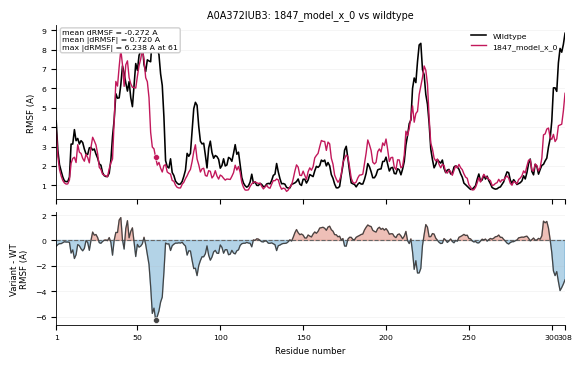

A0A372IUB3 | A0A372IUB3_1792_model_x_0


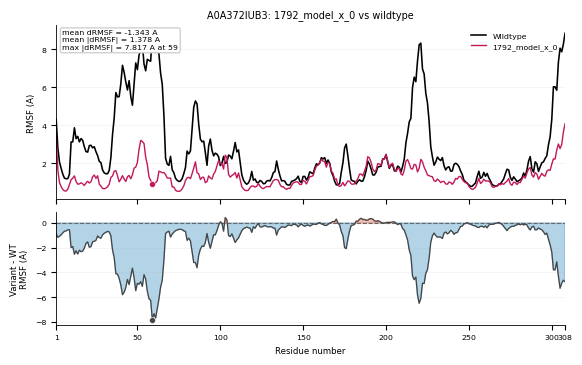

A0A2S1LEZ1 | A0A2S1LEZ1_362_New_17444_0


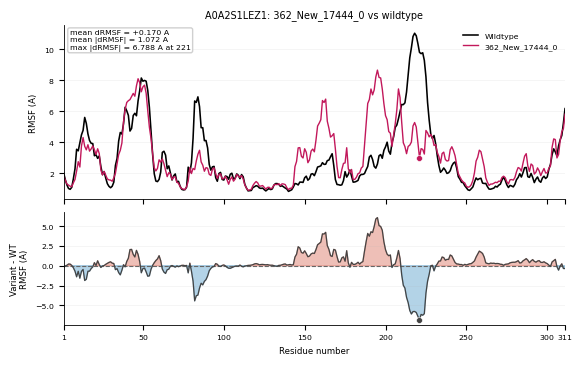

A0A2S1LEZ1 | A0A2S1LEZ1_337_New_17444_0


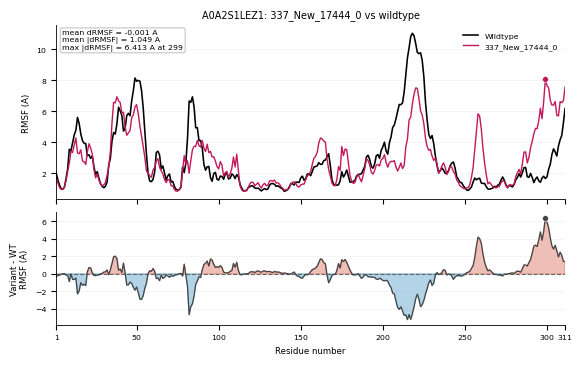

MGYP001421927114 | MGYP001421927114_1306_model_x_0


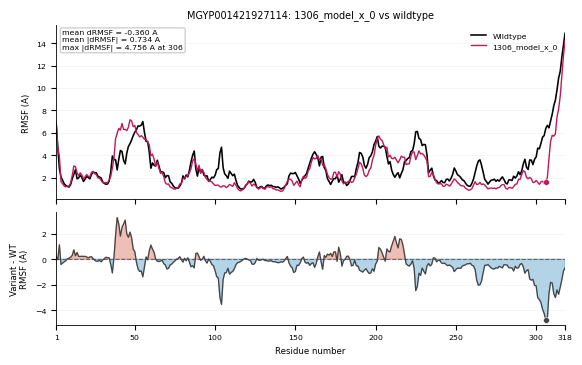

MGYP001421927114 | MGYP001421927114_1344_model_x_0


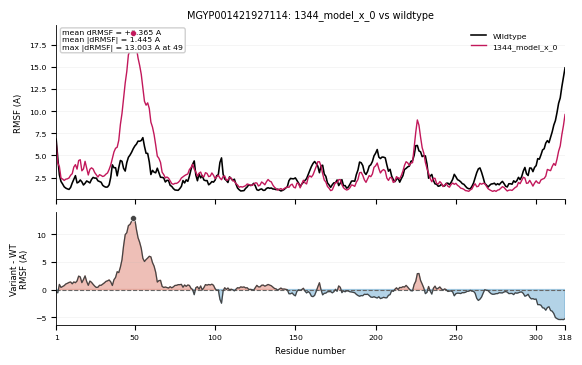

In [5]:
selected_pair_order_df = selected_variant_request_df.merge(
    pairwise_rmsf_summary_df[['family_id', 'sample_name']],
    on=['family_id', 'sample_name'],
    how='inner',
)

for row in selected_pair_order_df.itertuples(index=False):
    print(f"{row.family_id} | {row.sample_name}")
    plot_variant_pair_rmsf(
        family_id=row.family_id,
        sample_name=row.sample_name,
        md_rmsf_df=md_rmsf_df,
        variant_delta_rmsf_df=selected_variant_delta_rmsf_df,
    )
    plt.show()

## Family RMSF Overview Heatmaps

This section transfers the family RMSF overview plots from the original structure-analysis notebook. When `RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS` is set, variants below that median melting-temperature threshold are excluded from the overview heatmaps.

In [6]:
tm_summary_df = load_tsa_tm_delta_summary(
    result_summary_path=TSA_RESULT_SUMMARY_PATH,
    sample_catalog_df=md_rmsf_catalog_df,
)

all_rmsf_overview_variant_names = (
    md_rmsf_catalog_df.loc[~md_rmsf_catalog_df['is_wildtype'], 'sample_name']
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

tm_variant_lookup_df = (
    tm_summary_df.loc[
        tm_summary_df['sample_name'].notna() & (~tm_summary_df['is_wildtype']),
        ['family_id', 'sample_name', 'median_tm_celsius', 'delta_tm_to_wildtype_celsius'],
    ]
    .drop_duplicates(subset=['family_id', 'sample_name'])
    .reset_index(drop=True)
)

if RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS is None:
    overview_tm_summary_df = tm_summary_df.copy()
    overview_allowed_variant_names = all_rmsf_overview_variant_names
    excluded_rmsf_overview_variant_df = pd.DataFrame(
        columns=[
            'family_id', 'sample_name', 'median_tm_celsius',
            'delta_tm_to_wildtype_celsius', 'exclusion_reason',
        ]
    )
else:
    overview_tm_summary_df = filter_tm_summary_by_minimum_melting_temperature(
        tm_summary_df=tm_summary_df,
        minimum_median_tm_celsius=RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS,
        exclude_missing_tm=RMSF_OVERVIEW_EXCLUDE_MISSING_TM,
    )
    median_tm_lookup = {
        row.sample_name: float(row.median_tm_celsius)
        for row in tm_variant_lookup_df.itertuples(index=False)
        if pd.notna(row.sample_name) and pd.notna(row.median_tm_celsius)
    }
    low_tm_variant_name_set = {
        row.sample_name
        for row in tm_variant_lookup_df.itertuples(index=False)
        if pd.notna(row.sample_name)
        and pd.notna(row.median_tm_celsius)
        and float(row.median_tm_celsius) < float(RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS)
    }
    measured_variant_name_set = set(tm_variant_lookup_df['sample_name'].dropna().astype(str))

    if RMSF_OVERVIEW_EXCLUDE_MISSING_TM:
        overview_allowed_variant_names = [
            sample_name
            for sample_name in all_rmsf_overview_variant_names
            if sample_name in measured_variant_name_set
            and sample_name in median_tm_lookup
            and float(median_tm_lookup[sample_name]) >= float(RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS)
        ]
    else:
        overview_allowed_variant_names = [
            sample_name
            for sample_name in all_rmsf_overview_variant_names
            if sample_name not in low_tm_variant_name_set
        ]

    excluded_variant_rows = []
    for sample_name in all_rmsf_overview_variant_names:
        if sample_name in overview_allowed_variant_names:
            continue
        tm_match_df = tm_variant_lookup_df.loc[tm_variant_lookup_df['sample_name'] == sample_name]
        if tm_match_df.empty:
            family_id = sample_name.split('_', 1)[0]
            median_tm = np.nan
            delta_tm = np.nan
            reason = 'missing Tm'
        else:
            family_id = tm_match_df['family_id'].iloc[0]
            median_tm = tm_match_df['median_tm_celsius'].iloc[0]
            delta_tm = tm_match_df['delta_tm_to_wildtype_celsius'].iloc[0]
            if pd.isna(median_tm):
                reason = 'missing Tm'
            else:
                reason = f"median Tm < {float(RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS):0.1f} C"
        excluded_variant_rows.append(
            {
                'family_id': family_id,
                'sample_name': sample_name,
                'median_tm_celsius': median_tm,
                'delta_tm_to_wildtype_celsius': delta_tm,
                'exclusion_reason': reason,
            }
        )

    excluded_rmsf_overview_variant_df = pd.DataFrame(excluded_variant_rows)
    if not excluded_rmsf_overview_variant_df.empty:
        excluded_rmsf_overview_variant_df = excluded_rmsf_overview_variant_df.sort_values(
            ['family_id', 'median_tm_celsius', 'sample_name'],
            ascending=[True, True, True],
        ).reset_index(drop=True)

overview_md_rmsf_df, overview_variant_delta_rmsf_df = filter_rmsf_to_allowed_variants(
    md_rmsf_df=md_rmsf_df,
    variant_delta_rmsf_df=variant_delta_rmsf_df,
    allowed_variant_names=overview_allowed_variant_names,
)

overview_rmsf_tm_row_label_map = build_tm_delta_row_label_map(overview_tm_summary_df)
overview_rmsf_tm_sort_map = build_tm_median_sort_map(overview_tm_summary_df)

overview_variant_count_df = (
    overview_variant_delta_rmsf_df[['family_id', 'sample_name']]
    .drop_duplicates()
    .groupby('family_id', as_index=False)
    .agg(n_variants_plotted=('sample_name', 'size'))
)

display(overview_variant_count_df)

if RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS is not None and not excluded_rmsf_overview_variant_df.empty:
    display(excluded_rmsf_overview_variant_df)


,family_id,n_variants_plotted
0,A0A2S1LEZ1,8
1,A0A372IUB3,25
2,MGYP001421927114,6


A0A2S1LEZ1


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_A0A2S1LEZ1_RMSF.pdf


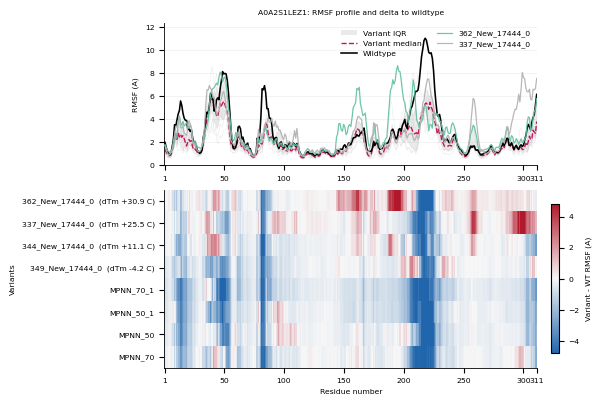

A0A372IUB3


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_A0A372IUB3_RMSF.pdf


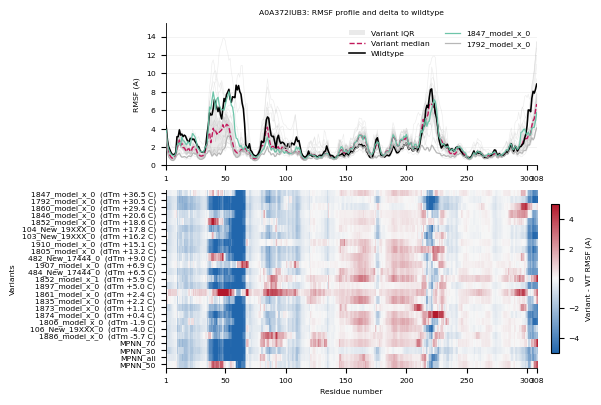

MGYP001421927114


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_MGYP001421927114_RMSF.pdf


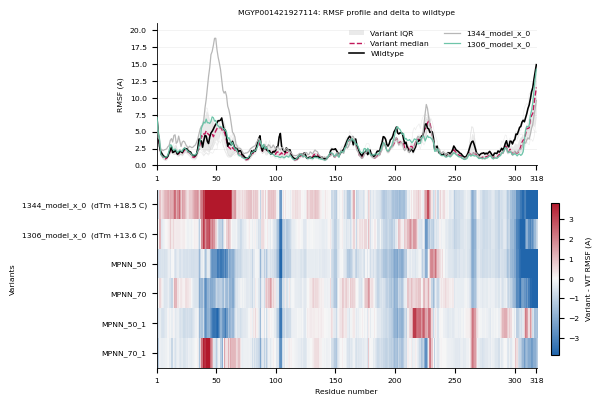

In [7]:
if SAVE_RMSF_OVERVIEW_PDFS:
    FIGURE4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for family_id in wildtype_labels:
    family_variant_count_series = overview_variant_count_df.loc[
        overview_variant_count_df['family_id'] == family_id,
        'n_variants_plotted',
    ]
    if family_variant_count_series.empty or int(family_variant_count_series.iloc[0]) == 0:
        print(f"{family_id}: no variants remain after the Tm filter")
        continue

    print(family_id)
    family_figure = plot_family_rmsf_overview(
        family_id=family_id,
        md_rmsf_df=overview_md_rmsf_df,
        variant_delta_rmsf_df=overview_variant_delta_rmsf_df,
        selected_variant_names=SELECTED_RMSF_VARIANTS_BY_FAMILY.get(family_id),
        sample_row_label_map=overview_rmsf_tm_row_label_map,
        sample_sort_value_map=overview_rmsf_tm_sort_map,
        figure_width_mm=RMSF_OVERVIEW_FIGURE_WIDTH_MM,
        figure_height_mm=RMSF_OVERVIEW_FIGURE_HEIGHT_MM,
        title_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
        label_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
        tick_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
        legend_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
    )
    if SAVE_RMSF_OVERVIEW_PDFS:
        output_path = FIGURE4_OUTPUT_DIR / f"Structure_{family_id}_RMSF.pdf"
        family_figure.savefig(output_path, bbox_inches='tight')
        print(output_path)
    plt.show()


## MD Variant Family Comparison Workflow

This section replaces the older standalone script workflow. It compares each wildtype with all of its matched variants using the combined per-metric CSVs and keeps the replicate handling explicit.

When TSA measurements are available, the variant labels in this workflow are annotated with the experimental melting-temperature shift to wildtype (`dTm`), mirroring the `Family RMSF Overview Heatmaps` section.

Change `FIGURE4_MD_METRIC_WINDOW` in the config cell above to switch between the 100 ns and 300 ns exports. Use `'latest'` if you want the notebook to automatically pick the longest shared window available.

The workflow keeps the replicate handling explicit:

1. Aggregate each metric at the replicate level first.
2. Summarize each system by the mean and standard deviation across replicates.
3. Compare each variant mean to its family wildtype mean.

The generated tables and plots are written to `sandra/MD_SIM/Round_3_additional_metric_csvs/` so the notebook and the saved outputs stay in sync.


In [8]:
if 'tm_summary_df' not in globals() or tm_summary_df is None or tm_summary_df.empty:
    md_rmsf_catalog_df = discover_md_rmsf_catalog(THERMALGAN_MD_ANALYSIS_DIR)
    tm_summary_df = load_tsa_tm_delta_summary(
        result_summary_path=TSA_RESULT_SUMMARY_PATH,
        sample_catalog_df=md_rmsf_catalog_df,
    )

md_variant_bundle = build_md_variant_analysis_bundle(
    metric_dir=FIGURE4_MD_METRIC_DIR,
    mutation_metadata_path=FIGURE4_MD_MUTATION_METADATA_PATH,
    metric_window=FIGURE4_MD_METRIC_WINDOW,
    tm_summary_df=tm_summary_df,
)

md_variant_tm_context_df = (
    md_variant_bundle.metadata_df.loc[
        ~md_variant_bundle.metadata_df['is_wildtype'],
        [
            'family', 'system', 'short_label', 'tm_display_label', 'mutation_count',
            'median_tm_celsius', 'wildtype_median_tm_celsius', 'delta_tm_to_wildtype_celsius',
        ],
    ]
    .rename(columns={'family': 'family_id', 'system': 'variant_system'})
    .sort_values(['family_id', 'mutation_count', 'variant_system'])
    .reset_index(drop=True)
)

MD_VARIANT_RUN_OUTPUT_ROOT = FIGURE4_MD_OUTPUT_ROOT / md_variant_bundle.metric_window_suffix
MD_VARIANT_PLOT_DIR = MD_VARIANT_RUN_OUTPUT_ROOT / 'plots'
MD_VARIANT_SUMMARY_DIR = MD_VARIANT_RUN_OUTPUT_ROOT / 'summary_tables'
GLOBAL_MD_VARIANT_SUMMARY_DIR = MD_VARIANT_SUMMARY_DIR / 'global'
FAMILY_MD_VARIANT_SUMMARY_DIR = MD_VARIANT_SUMMARY_DIR / 'family'

for directory in [
    MD_VARIANT_PLOT_DIR / 'rmsf',
    MD_VARIANT_PLOT_DIR / 'interaction_heatmaps',
    MD_VARIANT_PLOT_DIR / 'top_pair_deltas',
    MD_VARIANT_PLOT_DIR / 'neighborhood',
    MD_VARIANT_PLOT_DIR / 'secondary_structure',
    MD_VARIANT_PLOT_DIR / 'interaction_counts',
    MD_VARIANT_PLOT_DIR / 'interaction_boxplots',
    MD_VARIANT_PLOT_DIR / 'dashboard',
    GLOBAL_MD_VARIANT_SUMMARY_DIR,
    FAMILY_MD_VARIANT_SUMMARY_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

md_variant_tm_context_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'variant_experimental_tm_summary.csv',
    index=False,
)
md_variant_bundle.rmsf_summary_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'system_residue_rmsf_summary.csv',
    index=False,
)
md_variant_bundle.sasa_summary_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'system_residue_sasa_summary.csv',
    index=False,
)
md_variant_bundle.global_sasa_replicate_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'system_replicate_global_sasa_summary.csv',
    index=False,
)
md_variant_bundle.ss_residue_summary_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'system_residue_secondary_structure_summary.csv',
    index=False,
)
md_variant_bundle.ss_counts_summary_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'system_secondary_structure_fraction_summary.csv',
    index=False,
)
for metric_name, summary_df in md_variant_bundle.interaction_count_summary_by_metric.items():
    summary_df.to_csv(
        GLOBAL_MD_VARIANT_SUMMARY_DIR / f'system_frame_{metric_name}_summary.csv',
        index=False,
    )
for metric_name, replicate_df in md_variant_bundle.interaction_count_replicate_by_metric.items():
    replicate_df.to_csv(
        GLOBAL_MD_VARIANT_SUMMARY_DIR / f'system_replicate_{metric_name}_summary.csv',
        index=False,
    )
for metric_name, block_df in md_variant_bundle.interaction_count_block_by_metric.items():
    block_df.to_csv(
        GLOBAL_MD_VARIANT_SUMMARY_DIR / f'system_timeblock_{metric_name}_summary.csv',
        index=False,
    )
md_variant_bundle.rmsf_delta_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'all_variants_rmsf_delta_vs_wt.csv',
    index=False,
)
md_variant_bundle.sasa_delta_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'all_variants_sasa_delta_vs_wt.csv',
    index=False,
)
md_variant_bundle.ss_residue_delta_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'all_variants_secondary_structure_delta_vs_wt.csv',
    index=False,
)
for metric_name, delta_df in md_variant_bundle.interaction_count_delta_by_metric.items():
    delta_df.to_csv(
        GLOBAL_MD_VARIANT_SUMMARY_DIR / f'all_variants_{metric_name}_count_delta_vs_wt.csv',
        index=False,
    )
for metric_name, delta_df in md_variant_bundle.pair_delta_by_metric.items():
    delta_df.to_csv(
        GLOBAL_MD_VARIANT_SUMMARY_DIR / f'all_variants_{metric_name}_delta_vs_wt.csv',
        index=False,
    )
md_variant_bundle.variant_signal_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'variant_signal_summary.csv',
    index=False,
)
md_variant_bundle.family_pattern_summary_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'family_pattern_summary.csv',
    index=False,
)

for family_id in md_variant_bundle.family_ids:
    family_dir = FAMILY_MD_VARIANT_SUMMARY_DIR / family_id
    family_dir.mkdir(parents=True, exist_ok=True)

    md_variant_bundle.rmsf_delta_df.loc[
        md_variant_bundle.rmsf_delta_df['family'].eq(family_id)
    ].to_csv(family_dir / f'{family_id}_rmsf_delta_vs_wt.csv', index=False)
    md_variant_bundle.sasa_delta_df.loc[
        md_variant_bundle.sasa_delta_df['family'].eq(family_id)
    ].to_csv(family_dir / f'{family_id}_sasa_delta_vs_wt.csv', index=False)
    md_variant_bundle.global_sasa_replicate_df.loc[
        md_variant_bundle.global_sasa_replicate_df['family'].eq(family_id)
    ].to_csv(family_dir / f'{family_id}_global_sasa_summary.csv', index=False)
    md_variant_bundle.ss_residue_delta_df.loc[
        md_variant_bundle.ss_residue_delta_df['family'].eq(family_id)
    ].to_csv(family_dir / f'{family_id}_secondary_structure_delta_vs_wt.csv', index=False)

    for metric_name, delta_df in md_variant_bundle.interaction_count_delta_by_metric.items():
        delta_df.loc[delta_df['family'].eq(family_id)].to_csv(
            family_dir / f'{family_id}_{metric_name}_count_delta_vs_wt.csv',
            index=False,
        )

    for metric_name, delta_df in md_variant_bundle.pair_delta_by_metric.items():
        delta_df.loc[delta_df['family'].eq(family_id)].to_csv(
            family_dir / f'{family_id}_{metric_name}_delta_vs_wt.csv',
            index=False,
        )

print('Families loaded:', md_variant_bundle.family_ids)
print(
    'Resolved MD metric window:',
    md_variant_bundle.metric_window_suffix,
    f"(start={md_variant_bundle.metric_window_start}, stop={md_variant_bundle.metric_window_stop})",
)
print('Window-specific output root:', MD_VARIANT_RUN_OUTPUT_ROOT)
display(md_variant_tm_context_df)
display(
    md_variant_bundle.metadata_df[
        [
            'system', 'family', 'is_wildtype', 'mutation_count', 'mutation_resids',
            'mutation_labels', 'tm_display_label', 'median_tm_celsius',
            'delta_tm_to_wildtype_celsius',
        ]
    ]
)
display(
    md_variant_bundle.variant_signal_df[
        [
            'global_rank', 'family', 'variant_label', 'median_tm_celsius',
            'delta_tm_to_wildtype_celsius', 'composite_stabilizing_score',
            'delta_rmsf_neighborhood_mean', 'contact_gain_total',
            'saltbridge_gain_total', 'hbond_gain_total',
            'delta_sasa_neighborhood_mean', 'delta_ordered_ss_neighborhood_mean',
        ]
    ].head(10)
)


Families loaded: ['A0A2S1LEZ1', 'A0A372IUB3', 'MGYP001421927114']
Resolved MD metric window: 0_300000 (start=0, stop=300000)
Window-specific output root: /Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000


,family_id,variant_system,short_label,tm_display_label,mutation_count,median_tm_celsius,wildtype_median_tm_celsius,delta_tm_to_wildtype_celsius
0,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,362_New_17444_0,362_New_17444_0 (dTm +30.9 C),36,71.3416,40.4335,30.9081
1,A0A2S1LEZ1,A0A2S1LEZ1_344_New_17444_0,344_New_17444_0,344_New_17444_0 (dTm +11.1 C),37,51.5084,40.4335,11.0749
2,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,337_New_17444_0,337_New_17444_0 (dTm +25.5 C),38,65.9163,40.4335,25.4828
3,A0A372IUB3,A0A372IUB3_1897_model_x_0,1897_model_x_0,1897_model_x_0 (dTm +5.0 C),10,60.9217,55.9120,5.0097
4,A0A372IUB3,A0A372IUB3_1852_model_x_1,1852_model_x_1,1852_model_x_1 (dTm +5.9 C),12,61.8301,55.9120,5.9181
5,A0A372IUB3,A0A372IUB3_1860_model_x_0,1860_model_x_0,1860_model_x_0 (dTm +29.4 C),13,85.3535,55.9120,29.4415
6,A0A372IUB3,A0A372IUB3_1792_model_x_0,1792_model_x_0,1792_model_x_0 (dTm +30.5 C),14,86.3846,55.9120,30.4726
7,A0A372IUB3,A0A372IUB3_1847_model_x_0,1847_model_x_0,1847_model_x_0 (dTm +36.5 C),14,92.3836,55.9120,36.4716
8,A0A372IUB3,A0A372IUB3_1910_model_x_0,1910_model_x_0,1910_model_x_0 (dTm +15.1 C),14,70.9832,55.9120,15.0712
9,A0A372IUB3,A0A372IUB3_1805_model_x_0,1805_model_x_0,1805_model_x_0 (dTm +13.2 C),18,69.0969,55.9120,13.1849


,system,family,is_wildtype,mutation_count,mutation_resids,mutation_labels,tm_display_label,median_tm_celsius,delta_tm_to_wildtype_celsius
0,A0A2S1LEZ1,A0A2S1LEZ1,True,0,NaN,NaN,WT,40.4335,0.0000
1,A0A2S1LEZ1_362_New_17444_0,A0A2S1LEZ1,False,36,46 48 50 56 67 69 70 78 97 122 124 130 150 158 159 170 187 195 208 210 211 213 215 216 217 218 220 236 247 260 262 292 297 301 302 303,M46L;C48A;T50P;T56V;K67A;A69K;N70G;S78A;G97N;M122V;T124V;L130Y;S150A;L158E;A159L;M170T;A187S;T195S;A208E;T210G;M211V;G213I;A215K;T216L;L217K;T218G;L220K;L236M;M247V;Q260Y;D262G;F292L;D297E;Q301K;M...,362_New_17444_0 (dTm +30.9 C),71.3416,30.9081
2,A0A2S1LEZ1_344_New_17444_0,A0A2S1LEZ1,False,37,46 48 50 56 63 67 69 70 78 97 122 124 130 150 158 159 170 187 195 197 208 210 211 213 215 216 217 218 220 236 247 260 292 297 301 302 303,M46L;C48A;T50P;T56V;N63G;K67A;A69K;N70G;S78A;G97N;M122V;T124V;L130Y;S150A;L158E;A159L;M170T;A187S;T195S;F197L;A208E;T210G;M211V;G213I;A215K;T216A;L217K;T218G;L220K;L236M;M247V;Q260L;F292L;D297E;Q3...,344_New_17444_0 (dTm +11.1 C),51.5084,11.0749
3,A0A2S1LEZ1_337_New_17444_0,A0A2S1LEZ1,False,38,46 48 50 56 63 67 69 70 78 97 122 124 150 154 156 158 159 187 189 195 197 208 210 211 213 215 216 217 218 220 236 247 260 262 297 301 302 303,M46L;C48A;T50A;T56V;N63G;K67A;A69K;N70G;S78A;G97N;M122V;T124V;S150A;T154Y;L156I;L158E;A159L;A187S;Y189V;T195S;F197L;A208E;T210G;M211V;G213E;A215K;T216L;L217K;T218G;L220K;L236M;M247V;Q260L;D262G;D2...,337_New_17444_0 (dTm +25.5 C),65.9163,25.4828
4,A0A372IUB3,A0A372IUB3,True,0,NaN,NaN,WT,55.9120,0.0000
5,A0A372IUB3_1897_model_x_0,A0A372IUB3,False,10,34 43 70 127 128 132 161 207 253 278,V34I;G43A;N70G;Q127Y;T128V;Q132V;K161G;Q207E;F253Y;Q278K,1897_model_x_0 (dTm +5.0 C),60.9217,5.0097
6,A0A372IUB3_1852_model_x_1,A0A372IUB3,False,12,43 70 127 128 161 168 207 246 253 278 289 303,G43A;N70G;Q127Y;T128V;K161G;T168Q;Q207E;K246R;F253Y;Q278K;E289K;C303M,1852_model_x_1 (dTm +5.9 C),61.8301,5.9181
7,A0A372IUB3_1860_model_x_0,A0A372IUB3,False,13,34 43 57 70 127 128 131 168 207 246 253 278 303,V34I;G43A;A57V;N70G;Q127Y;T128V;R131K;T168Q;Q207E;K246R;F253Y;Q278K;C303M,1860_model_x_0 (dTm +29.4 C),85.3535,29.4415
8,A0A372IUB3_1792_model_x_0,A0A372IUB3,False,14,34 43 70 127 128 132 207 219 246 253 263 265 278 303,V34I;G43A;N70G;Q127Y;T128V;Q132V;Q207E;Y219L;K246R;F253Y;Y263I;I265L;Q278K;C303M,1792_model_x_0 (dTm +30.5 C),86.3846,30.4726
9,A0A372IUB3_1847_model_x_0,A0A372IUB3,False,14,34 43 70 127 132 138 154 161 168 170 219 246 278 303,V34I;G43A;N70G;Q127Y;Q132V;N138E;T154A;K161G;T168Q;F170L;Y219L;K246R;Q278K;C303M,1847_model_x_0 (dTm +36.5 C),92.3836,36.4716


,global_rank,family,variant_label,median_tm_celsius,delta_tm_to_wildtype_celsius,composite_stabilizing_score,delta_rmsf_neighborhood_mean,contact_gain_total,saltbridge_gain_total,hbond_gain_total,delta_sasa_neighborhood_mean,delta_ordered_ss_neighborhood_mean
0,1.0,A0A372IUB3,482_New_17444_0 (dTm +9.0 C),64.8800,8.9680,0.710526,-0.108296,262.135244,9.208333,51.147089,-0.222394,-0.006756
1,2.0,A0A372IUB3,1907_model_x_0 (dTm +6.9 C),62.8599,6.9479,0.692982,-0.016317,272.114178,6.291600,54.074467,-0.925649,-0.003983
2,3.0,A0A372IUB3,103_New_19XXX_0 (dTm +16.2 C),72.1360,16.2240,0.684211,-0.093256,261.778822,7.446733,52.115156,-0.101713,-0.001281
3,4.0,A0A372IUB3,1846_model_x_0 (dTm +20.6 C),76.5092,20.5972,0.675439,-0.251089,175.305911,6.215156,37.526000,-0.545397,0.020977
4,5.0,A0A372IUB3,104_New_19XXX_0 (dTm +17.8 C),73.7585,17.8465,0.657895,-0.119325,241.994733,6.146222,51.116978,-0.074149,0.016041
5,6.0,A0A372IUB3,484_New_17444_0 (dTm +6.5 C),62.3620,6.4500,0.622807,0.062746,245.522933,7.846867,49.756756,0.103861,0.013997
6,7.0,A0A372IUB3,1852_model_x_0 (dTm +18.6 C),74.5336,18.6216,0.578947,0.027723,240.801333,9.894378,52.765378,0.345380,-0.003690
7,8.0,A0A372IUB3,1805_model_x_0 (dTm +13.2 C),69.0969,13.1849,0.552632,-0.056817,157.173444,6.925422,32.305822,-0.797733,-0.000275
8,9.0,A0A372IUB3,1792_model_x_0 (dTm +30.5 C),86.3846,30.4726,0.526316,-0.260208,143.845089,5.059978,28.839156,-0.371391,0.012460
9,10.0,A0A372IUB3,1897_model_x_0 (dTm +5.0 C),60.9217,5.0097,0.517544,-0.348229,112.343244,4.652022,22.687956,-1.837497,0.016611


### How residues and pairs of interest are ranked

The notebook uses **replicate-aware effect-size summaries**, not a formal residue-wise significance test.

- For each residue, the WT and the variant are each summarized by a **mean RMSF across replicates** and a **replicate standard deviation**.
- The main residue ranking statistic is the **mean absolute RMSF delta to WT** across variants in the same family.
- A second scale-aware statistic is also reported:
  `standardized delta = (variant mean - WT mean) / sqrt(variant SD^2 + WT SD^2)`.
- This standardized delta tells you whether the WT-vs-variant shift is large relative to replicate-to-replicate spread, but it is still an **effect-size score**, not a p-value.
- For contact, salt-bridge, and H-bond heatmaps, the “most varied to WT” pairs are ranked by the **largest absolute occupancy shift to WT** across variants in that family.

So the current workflow is statistical in the sense that it uses replicate means and replicate variation, but it does **not** claim formal significance testing or multiple-testing correction.


In [9]:
md_family_residue_interest_tables = {
    family_id: compute_md_family_residue_interest_df(
        rmsf_delta_df=md_variant_bundle.rmsf_delta_df,
        family_id=family_id,
    )
    for family_id in md_variant_bundle.family_ids
}
md_family_pair_interest_tables = {
    family_id: {
        metric_name: compute_md_family_pair_interest_df(
            pair_summary_df=md_variant_bundle.pair_summary_by_metric[metric_name],
            metadata_df=md_variant_bundle.metadata_df,
            family_id=family_id,
        )
        for metric_name in MD_VARIANT_PAIR_METRICS
    }
    for family_id in md_variant_bundle.family_ids
}

for family_id in md_variant_bundle.family_ids:
    print()
    print(f'{family_id}: top RMSF-ranked residues')
    display(
        md_family_residue_interest_tables[family_id][
            [
                'interest_rank', 'resid', 'resname',
                'mean_delta_rmsf', 'mean_abs_delta_rmsf',
                'mean_abs_standardized_delta_rmsf',
                'fraction_variants_lower_than_wt',
            ]
        ].head(12)
    )



A0A2S1LEZ1: top RMSF-ranked residues


,interest_rank,resid,resname,mean_delta_rmsf,mean_abs_delta_rmsf,mean_abs_standardized_delta_rmsf,fraction_variants_lower_than_wt
0,1,50,PRO,4.327301,4.327301,1.103479,0.000000
1,2,52,THR,3.413107,3.413107,1.137123,0.000000
2,3,53,GLY,3.382226,3.382226,1.267114,0.000000
3,4,51,ASN,3.264662,3.264662,0.984510,0.000000
4,5,44,ASP,2.886134,2.948322,0.826730,0.333333
5,6,43,LEU,2.635000,2.911980,0.871408,0.333333
6,7,45,ILE,2.550281,2.880587,0.739221,0.333333
7,8,46,LEU,2.292015,2.753742,0.673360,0.333333
8,9,54,PHE,2.728484,2.728484,0.841056,0.000000
9,10,47,GLN,2.361310,2.648631,0.632666,0.333333



A0A372IUB3: top RMSF-ranked residues


,interest_rank,resid,resname,mean_delta_rmsf,mean_abs_delta_rmsf,mean_abs_standardized_delta_rmsf,fraction_variants_lower_than_wt
0,1,50,SER,2.980038,2.980038,0.785875,0.000000
1,2,56,ASP,-1.453941,1.453941,0.707454,1.000000
2,3,109,TYR,-1.341671,1.341671,1.969796,1.000000
3,4,308,VAL,-0.195022,1.259272,1.449003,0.642857
4,5,38,MET,1.244679,1.244679,0.392785,0.000000
5,6,41,GLY,0.841506,1.184251,0.624182,0.285714
6,7,211,LYS,1.163769,1.163769,0.655840,0.000000
7,8,40,GLN,0.691056,1.162164,0.583861,0.428571
8,9,39,PRO,0.542817,1.146487,0.533843,0.428571
9,10,42,LYS,0.823106,1.140083,0.602454,0.214286



MGYP001421927114: top RMSF-ranked residues


,interest_rank,resid,resname,mean_delta_rmsf,mean_abs_delta_rmsf,mean_abs_standardized_delta_rmsf,fraction_variants_lower_than_wt
0,1,203,THR,3.553485,3.553485,2.669373,0.0
1,2,46,ASP,2.484648,2.484648,0.771868,0.0
2,3,42,GLY,2.446564,2.446564,1.009788,0.0
3,4,312,CYS,-2.411255,2.411255,0.866571,1.0
4,5,56,PHE,2.341457,2.341457,0.786107,0.0
5,6,43,LYS,2.310098,2.310098,0.861044,0.0
6,7,39,ILE,2.211056,2.211056,1.610907,0.0
7,8,45,LEU,2.198892,2.198892,0.769583,0.0
8,9,59,ARG,2.192585,2.192585,0.806415,0.0
9,10,315,LEU,-2.186688,2.186688,0.834844,1.0


### Per-family RMSF overlays

How to read these panels:

- **Black line**: WT mean RMSF across the WT replicates.
- **Gray band**: WT replicate standard deviation around that mean.
- **Colored line**: one variant mean RMSF across its replicates.
- **Faint colored band**: replicate standard deviation for that variant.
- **Downward triangles below the x-axis**: mutation positions from `mutation_metadata.csv`.

Interpretation: when the colored variant line sits below the WT line in a residue region, that region is less flexible in the variant than in the WT.


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/rmsf/A0A2S1LEZ1_rmsf_vs_wt.png


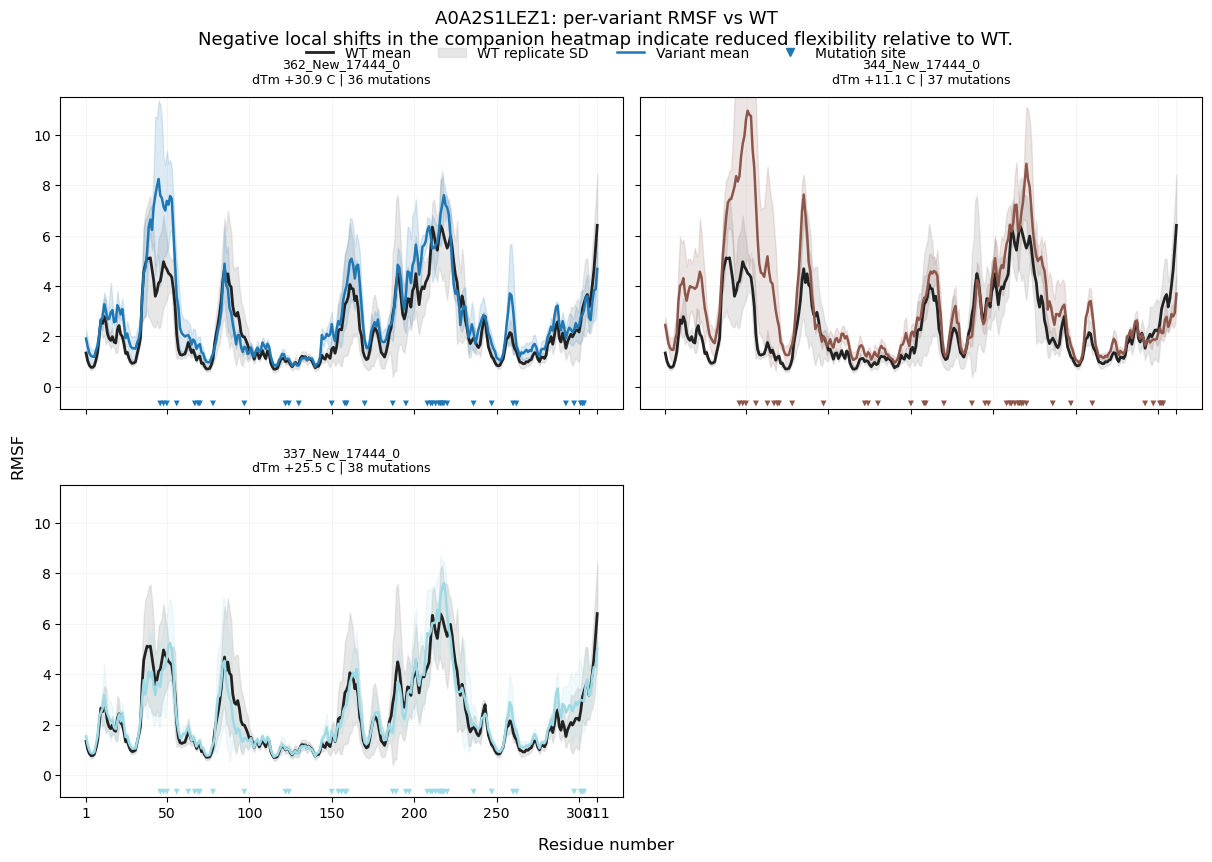

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/rmsf/A0A372IUB3_rmsf_vs_wt.png


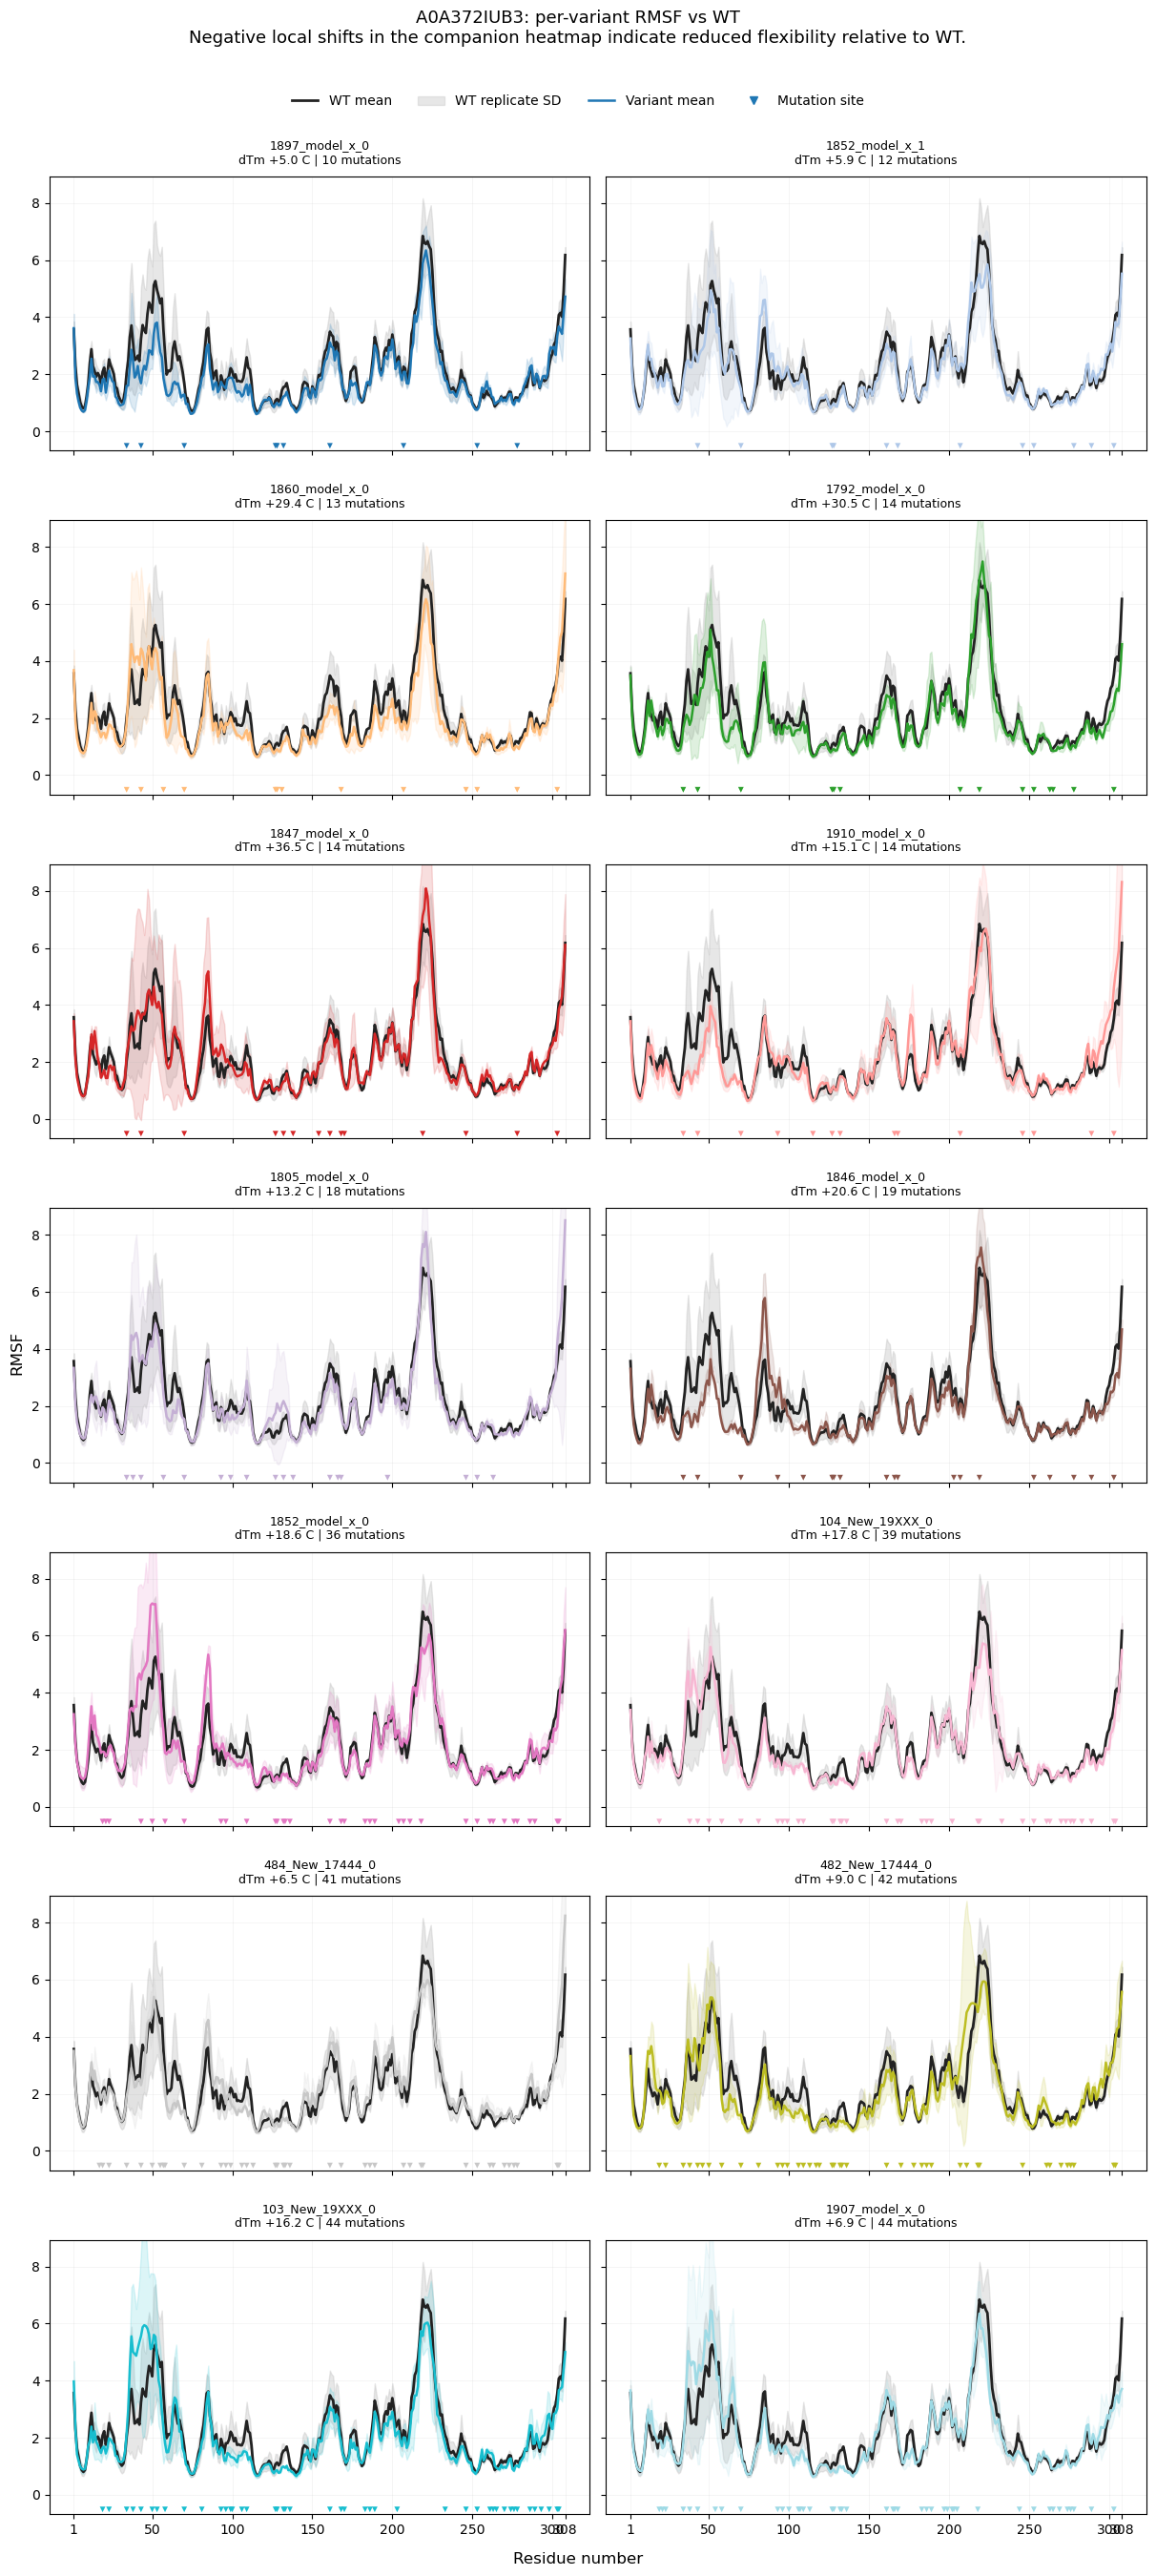

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/rmsf/MGYP001421927114_rmsf_vs_wt.png


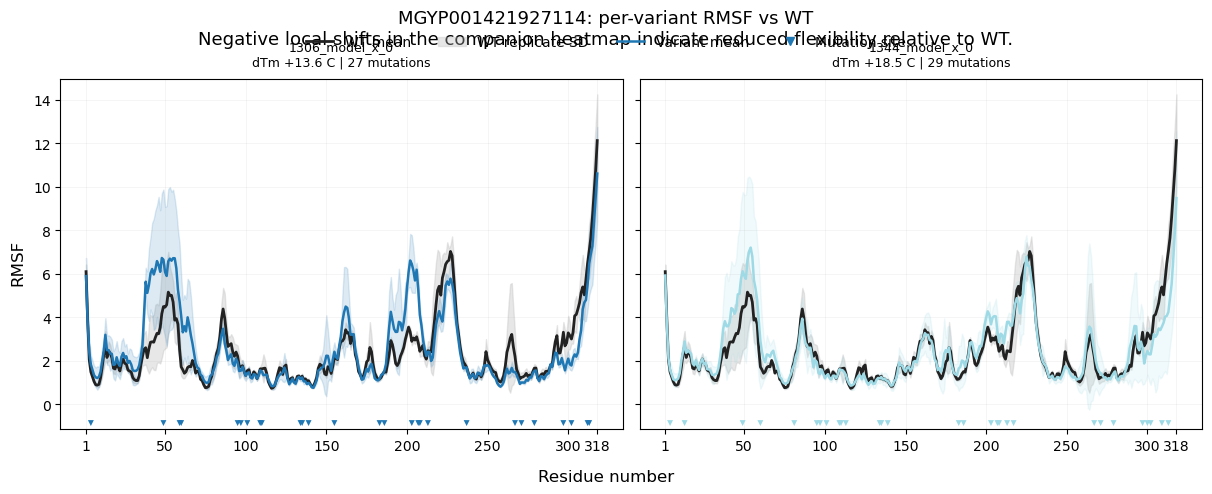

In [10]:
for family_id in md_variant_bundle.family_ids:
    figure = plot_md_family_rmsf_panels(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        rmsf_summary_df=md_variant_bundle.rmsf_summary_df,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'rmsf' / f'{family_id}_rmsf_vs_wt.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Delta RMSF heatmaps

How to read these heatmaps:

- **Each row** is one variant in a WT family.
- **Each column** is one residue number.
- **Color** is `variant mean RMSF - WT mean RMSF`.
- **Blue** means the variant is less flexible than WT at that residue.
- **Red** means the variant is more flexible than WT at that residue.
- **Black squares** mark mutated residues.

These are direct mean differences after replicate aggregation. They are not p-values.


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/rmsf/A0A2S1LEZ1_delta_rmsf_heatmap.png


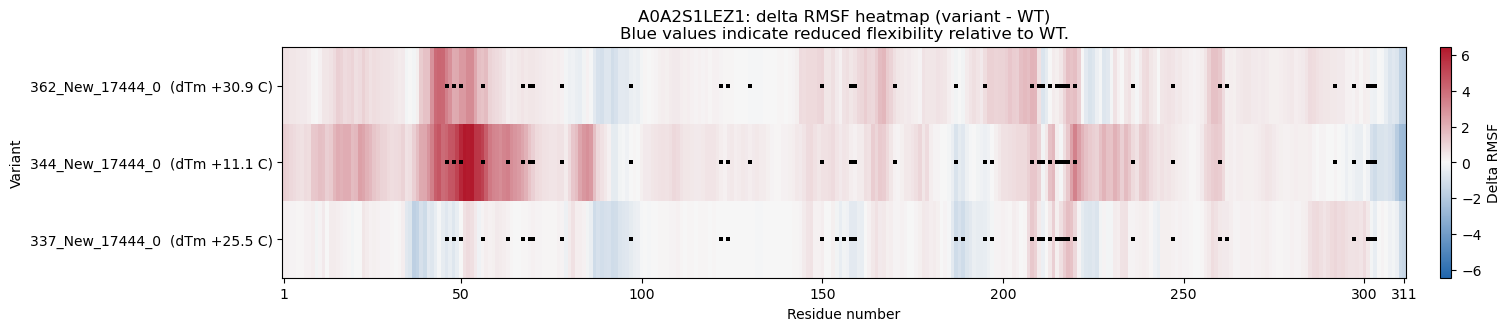

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/rmsf/A0A372IUB3_delta_rmsf_heatmap.png


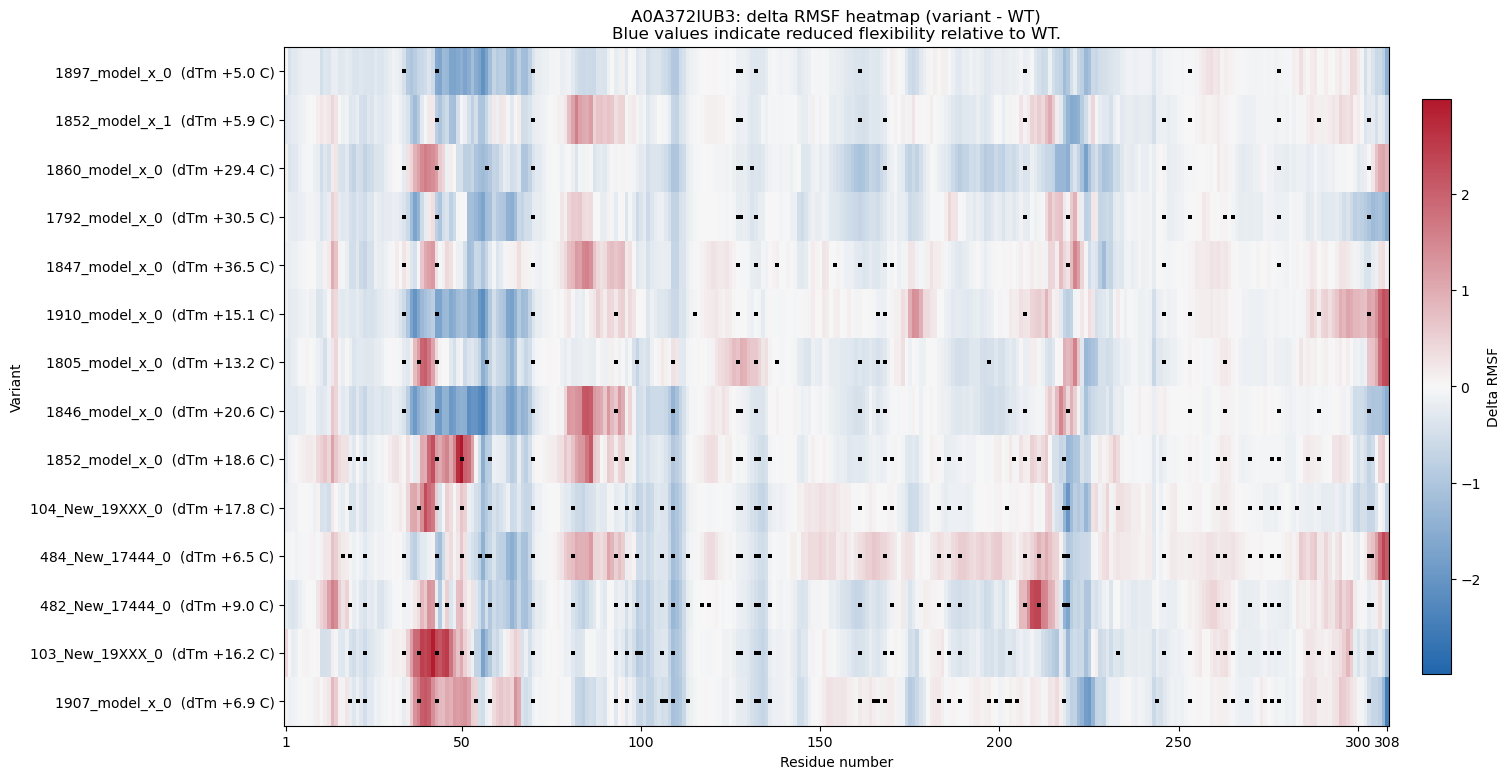

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/rmsf/MGYP001421927114_delta_rmsf_heatmap.png


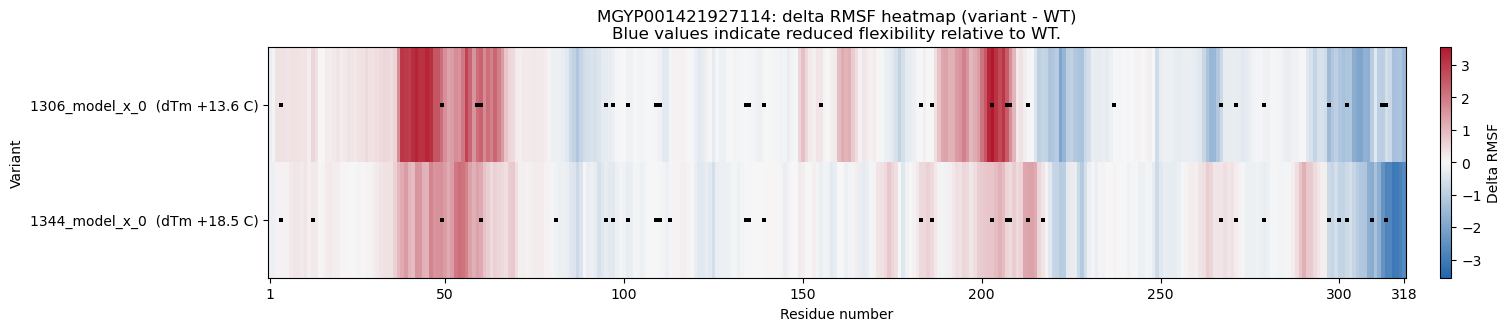

In [11]:
for family_id in md_variant_bundle.family_ids:
    figure = plot_md_family_delta_heatmap(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        delta_df=md_variant_bundle.rmsf_delta_df,
        value_column='delta_rmsf',
        title=(
            f'{family_id}: delta RMSF heatmap (variant - WT)\n'
            'Blue values indicate reduced flexibility relative to WT.'
        ),
        colorbar_label='Delta RMSF',
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'rmsf' / f'{family_id}_delta_rmsf_heatmap.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Interaction-count trajectories relative to WT

These plots show the total interaction counts over time for each family, centered on the WT trajectory.

How to read these panels:

- **One row per metric**: residue contacts, H-bonds, and salt bridges.
- **Colored lines**: variant mean count across replicates minus the WT mean count at the same timepoint.
- **Black horizontal line at zero**: the WT mean trajectory after centering.
- **Gray band around zero**: WT replicate standard deviation at each timepoint.
- **Positive values** mean the variant has more of that interaction type than WT at that timepoint; **negative values** mean fewer.

The x-axis is trajectory time in ns, inferred from the exported frame spacing used in the combined MD metric CSVs.


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/interaction_counts/A0A2S1LEZ1_interaction_count_trajectories.png


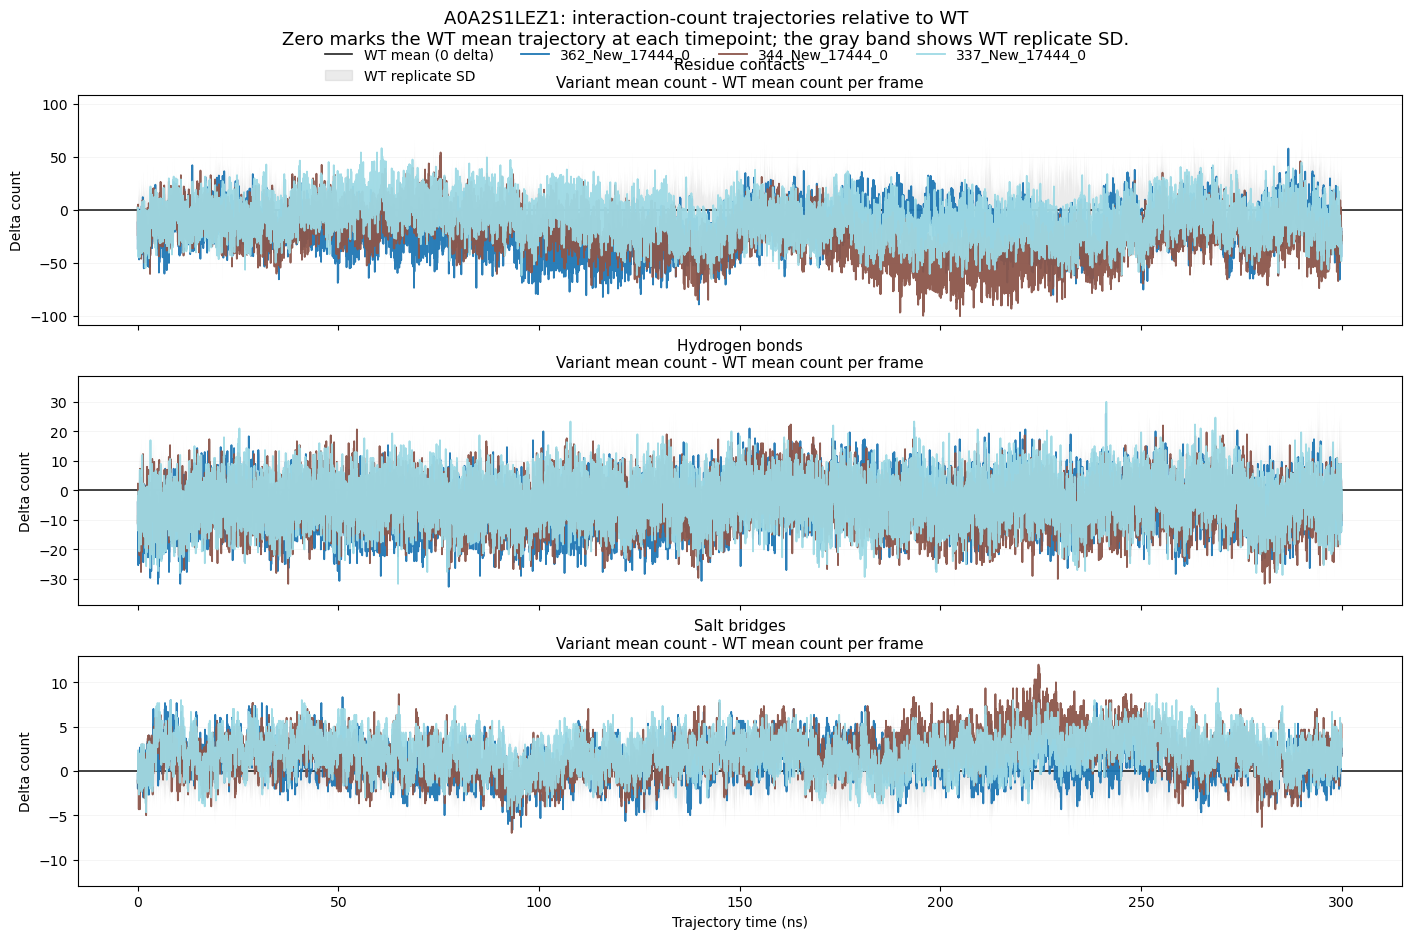

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/interaction_counts/A0A372IUB3_interaction_count_trajectories.png


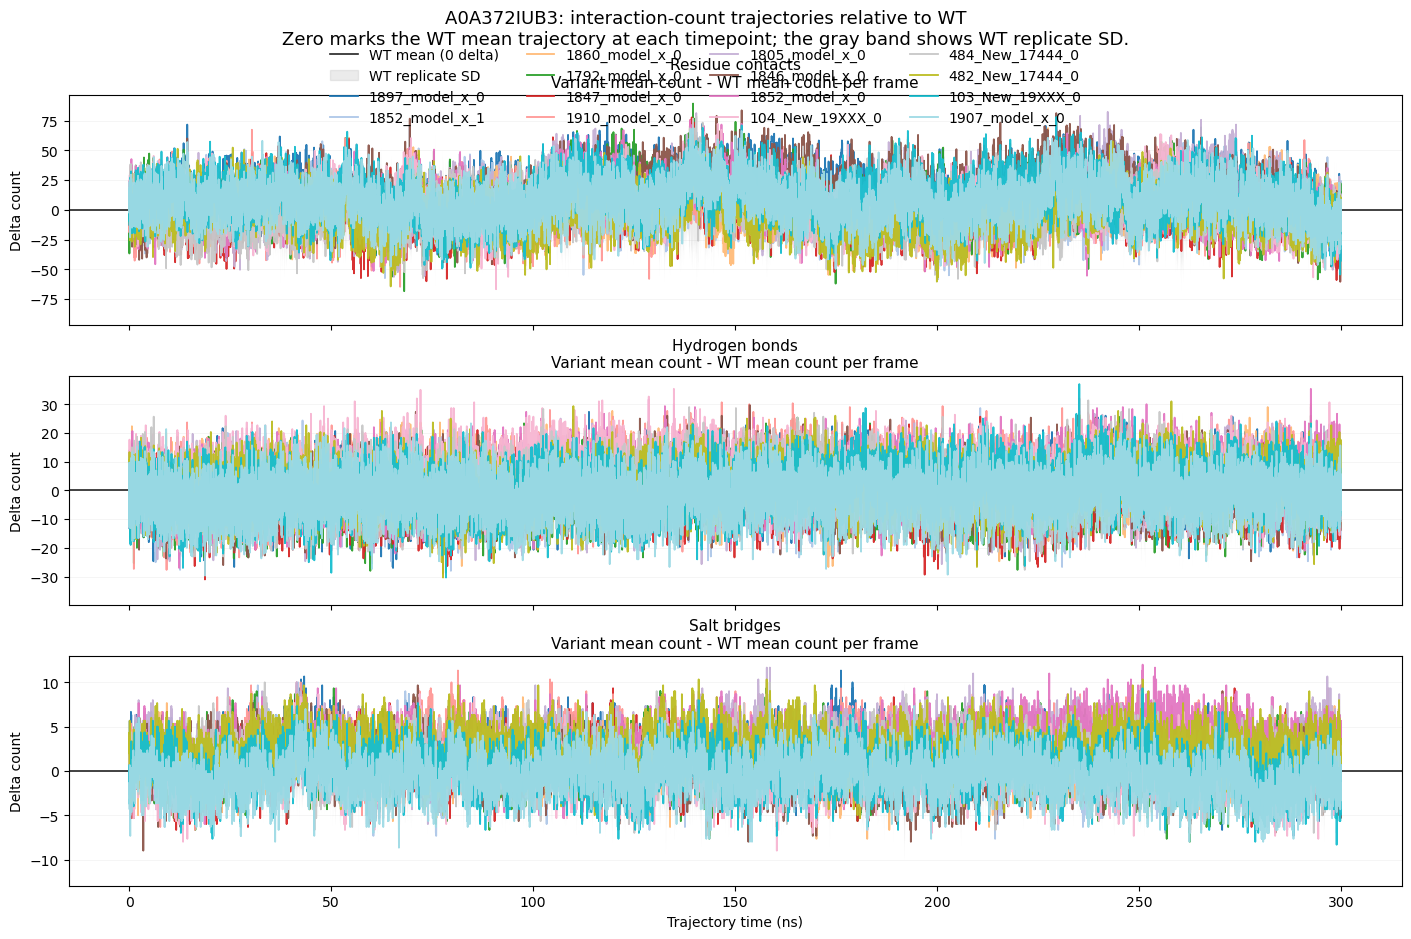

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/interaction_counts/MGYP001421927114_interaction_count_trajectories.png


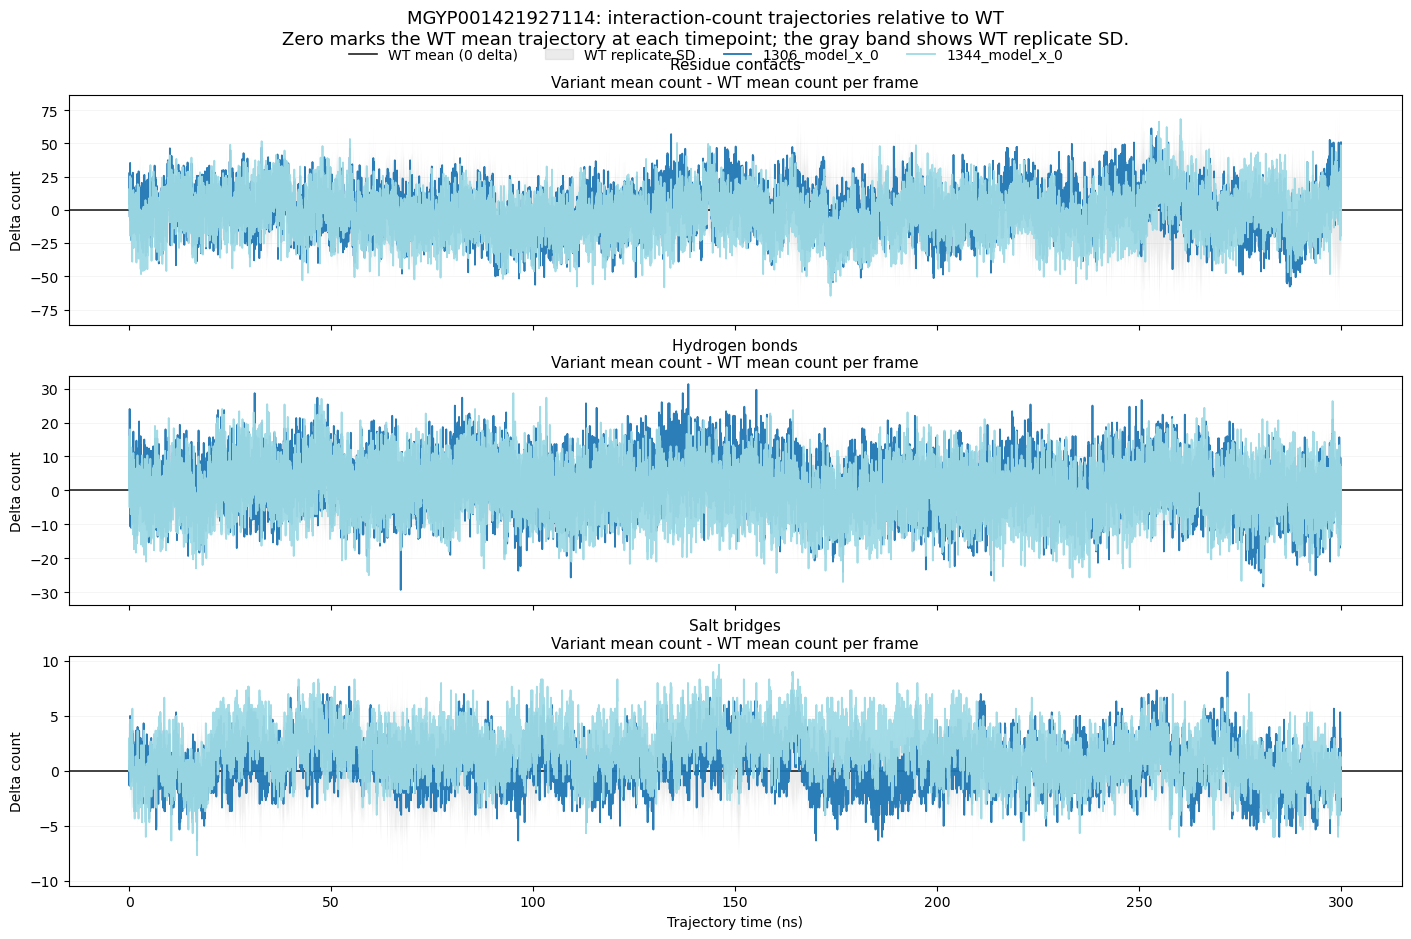

In [12]:
for family_id in md_variant_bundle.family_ids:
    figure = helper_fugure4.plot_md_family_interaction_count_trajectories(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        interaction_count_summary_by_metric=md_variant_bundle.interaction_count_summary_by_metric,
        interaction_count_delta_by_metric=md_variant_bundle.interaction_count_delta_by_metric,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'interaction_counts' / f'{family_id}_interaction_count_trajectories.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### WT-median-normalized interaction-count and SASA boxplots

These plots show the same interaction metrics after dividing each family by the wildtype median for that metric, so WT is the reference at `1.0`.

How to read these panels:

- **One box per system**: WT plus all variants in the family.
- **Normalization**: each value is divided by the WT median for that metric within the same family, so `1.0` means WT-like, `> 1.0` is higher than WT, and `< 1.0` is lower.
- **Contacts, H-bonds, and salt bridges** use the distribution of per-frame replicate-mean counts across the analysis window before WT-median normalization.
- **Time-block stars for counts**: contacts, H-bonds, and salt bridges use a distribution-shift test on contiguous 100-frame block means (about 2 ns per block), with permutation KS p-values and Benjamini-Hochberg correction within each family.
- **Global SASA** uses residue-summed mean SASA per replicate over the same window before WT-median normalization, because the current combined SASA export is window-averaged rather than framewise.
- **SASA stars** use a Welch test on replicate means, also with Benjamini-Hochberg correction within each family.
- **Radius of gyration** is not included here because it is not present in the current combined Figure 4 metric exports.


,family,short_label,metric_label,variant_mean,wildtype_mean,mean_difference,test_name,n_variant_samples,n_wildtype_samples,p_value,p_value_fdr,stars,direction_vs_wt
0,A0A2S1LEZ1,337_New_17444_0,Global SASA,14734.375233,14516.432677,217.942556,welch_ttest,3,3,0.190272,0.194327,,higher
1,A0A2S1LEZ1,344_New_17444_0,Global SASA,15026.603920,14516.432677,510.171244,welch_ttest,3,3,0.034141,0.040970,*,higher
2,A0A2S1LEZ1,362_New_17444_0,Global SASA,14812.539797,14516.432677,296.107120,welch_ttest,3,3,0.194327,0.194327,,higher
3,A0A2S1LEZ1,337_New_17444_0,Hydrogen bonds,158.056956,161.262733,-3.205778,block_permutation_ks,450,450,0.000500,0.000666,***,lower
4,A0A2S1LEZ1,344_New_17444_0,Hydrogen bonds,156.508822,161.262733,-4.753911,block_permutation_ks,450,450,0.000500,0.000666,***,lower
5,A0A2S1LEZ1,362_New_17444_0,Hydrogen bonds,156.187667,161.262733,-5.075067,block_permutation_ks,450,450,0.000500,0.000666,***,lower
6,A0A2S1LEZ1,337_New_17444_0,Residue contacts,825.664800,833.783422,-8.118622,block_permutation_ks,450,450,0.000500,0.000666,***,lower
7,A0A2S1LEZ1,344_New_17444_0,Residue contacts,811.131044,833.783422,-22.652378,block_permutation_ks,450,450,0.000500,0.000666,***,lower
8,A0A2S1LEZ1,362_New_17444_0,Residue contacts,816.069644,833.783422,-17.713778,block_permutation_ks,450,450,0.000500,0.000666,***,lower
9,A0A2S1LEZ1,337_New_17444_0,Salt bridges,16.532578,14.524867,2.007711,block_permutation_ks,450,450,0.000500,0.000666,***,higher


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/interaction_boxplots/A0A2S1LEZ1_absolute_metric_boxplots.png


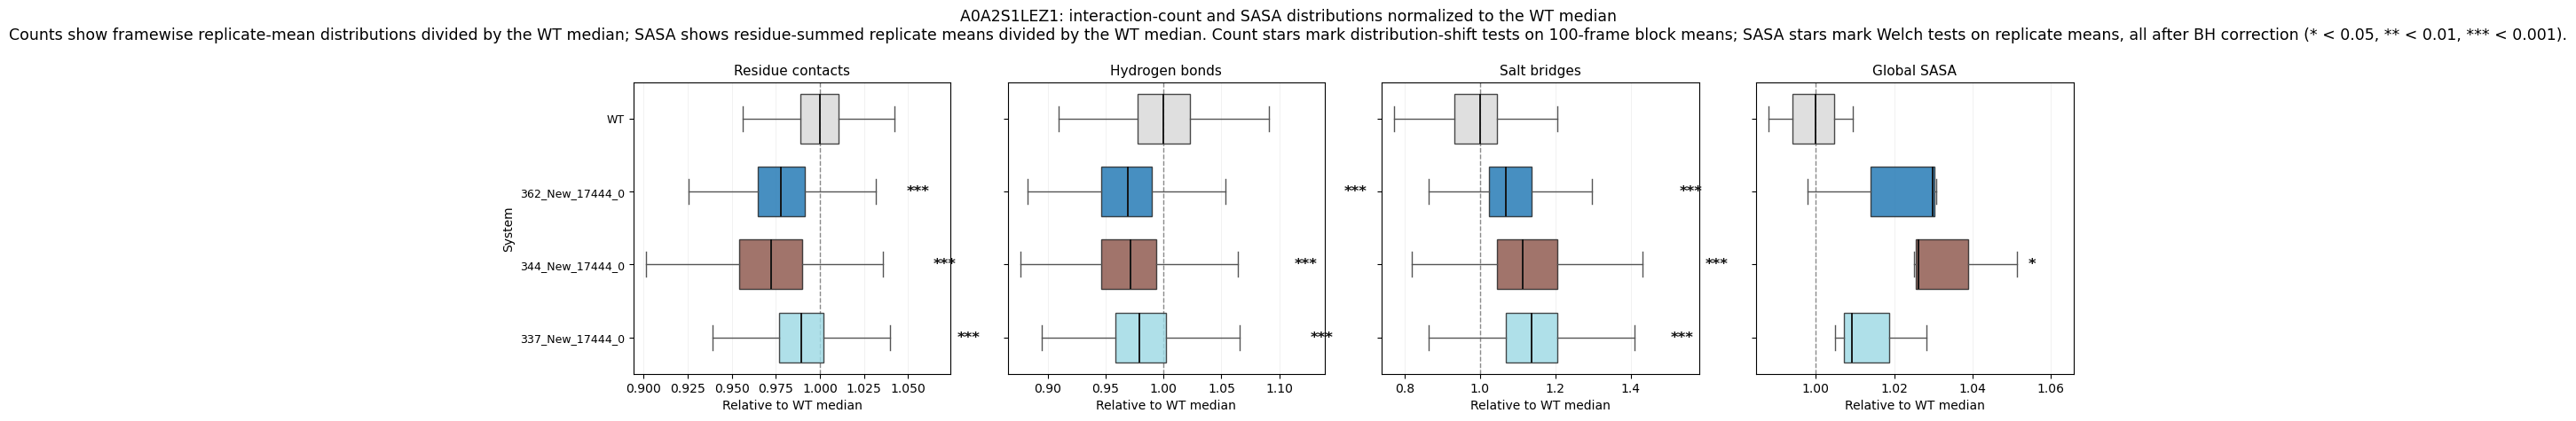

,family,short_label,metric_label,variant_mean,wildtype_mean,mean_difference,test_name,n_variant_samples,n_wildtype_samples,p_value,p_value_fdr,stars,direction_vs_wt
0,A0A372IUB3,103_New_19XXX_0,Global SASA,14854.711331,14959.320812,-104.609481,welch_ttest,3,3,0.495903,0.617124,,lower
1,A0A372IUB3,104_New_19XXX_0,Global SASA,14911.884399,14959.320812,-47.436413,welch_ttest,3,3,0.744351,0.817464,,lower
2,A0A372IUB3,1792_model_x_0,Global SASA,14901.118281,14959.320812,-58.202531,welch_ttest,3,3,0.759074,0.817464,,lower
3,A0A372IUB3,1805_model_x_0,Global SASA,14657.372489,14959.320812,-301.948323,welch_ttest,3,3,0.143450,0.183817,,lower
4,A0A372IUB3,1846_model_x_0,Global SASA,14888.420499,14959.320812,-70.900313,welch_ttest,3,3,0.663855,0.807523,,lower
5,A0A372IUB3,1847_model_x_0,Global SASA,14990.829483,14959.320812,31.508671,welch_ttest,3,3,0.848744,0.864176,,higher
6,A0A372IUB3,1852_model_x_0,Global SASA,15024.532789,14959.320812,65.211978,welch_ttest,3,3,0.677743,0.807523,,higher
7,A0A372IUB3,1852_model_x_1,Global SASA,14899.791816,14959.320812,-59.528995,welch_ttest,3,3,0.791830,0.821157,,lower
8,A0A372IUB3,1860_model_x_0,Global SASA,15004.655198,14959.320812,45.334387,welch_ttest,3,3,0.752195,0.817464,,higher
9,A0A372IUB3,1897_model_x_0,Global SASA,14563.599257,14959.320812,-395.721555,welch_ttest,3,3,0.084185,0.117860,,lower


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/interaction_boxplots/A0A372IUB3_absolute_metric_boxplots.png


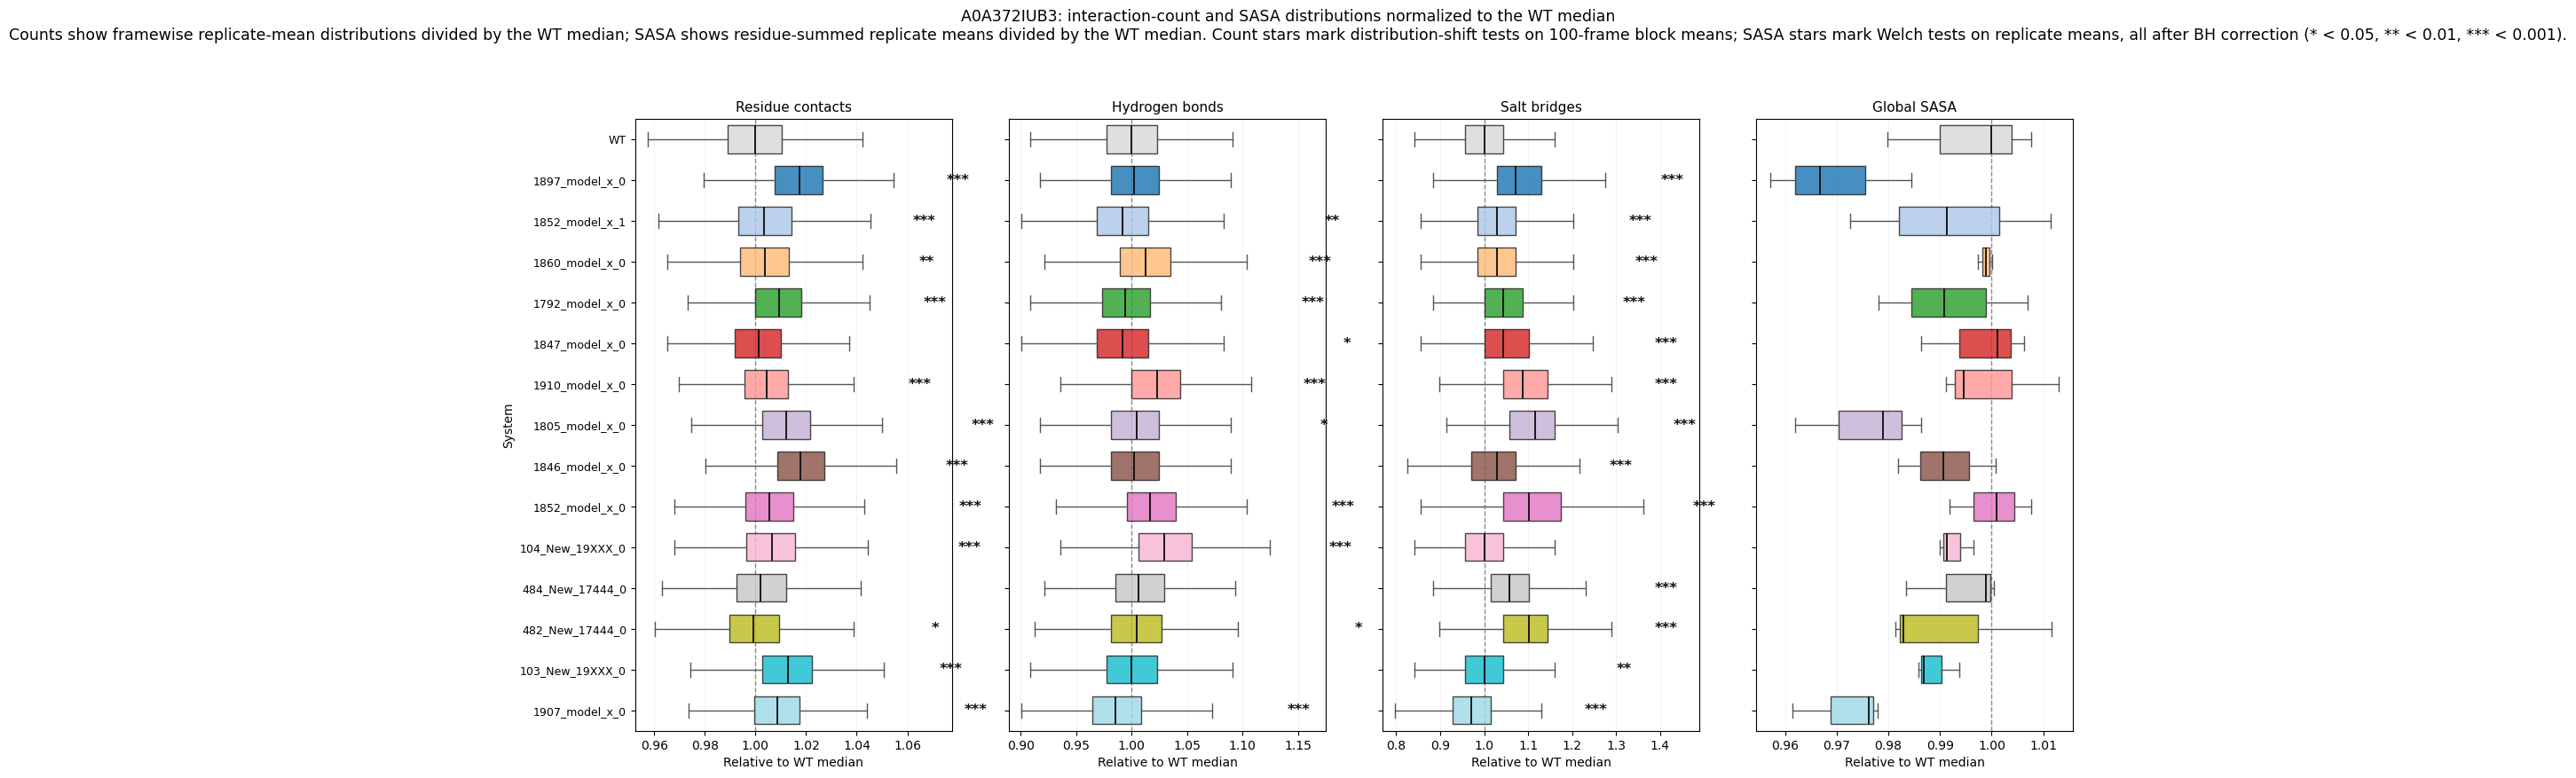

,family,short_label,metric_label,variant_mean,wildtype_mean,mean_difference,test_name,n_variant_samples,n_wildtype_samples,p_value,p_value_fdr,stars,direction_vs_wt
0,MGYP001421927114,1306_model_x_0,Global SASA,15146.944690,15201.517503,-54.572813,welch_ttest,3,3,0.803175,0.893243,,lower
1,MGYP001421927114,1344_model_x_0,Global SASA,15179.156129,15201.517503,-22.361374,welch_ttest,3,3,0.893243,0.893243,,lower
2,MGYP001421927114,1306_model_x_0,Hydrogen bonds,157.180267,155.439978,1.740289,block_permutation_ks,450,450,0.000500,0.001000,***,higher
3,MGYP001421927114,1344_model_x_0,Hydrogen bonds,155.272200,155.439978,-0.167778,block_permutation_ks,450,450,0.096452,0.154323,,lower
4,MGYP001421927114,1306_model_x_0,Residue contacts,844.828133,845.148067,-0.319933,block_permutation_ks,450,450,0.645177,0.860237,,lower
5,MGYP001421927114,1344_model_x_0,Residue contacts,841.299089,845.148067,-3.848978,block_permutation_ks,450,450,0.000500,0.001000,***,lower
6,MGYP001421927114,1306_model_x_0,Salt bridges,20.269489,19.531511,0.737978,block_permutation_ks,450,450,0.000500,0.001000,***,higher
7,MGYP001421927114,1344_model_x_0,Salt bridges,21.348578,19.531511,1.817067,block_permutation_ks,450,450,0.000500,0.001000,***,higher


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/interaction_boxplots/MGYP001421927114_absolute_metric_boxplots.png


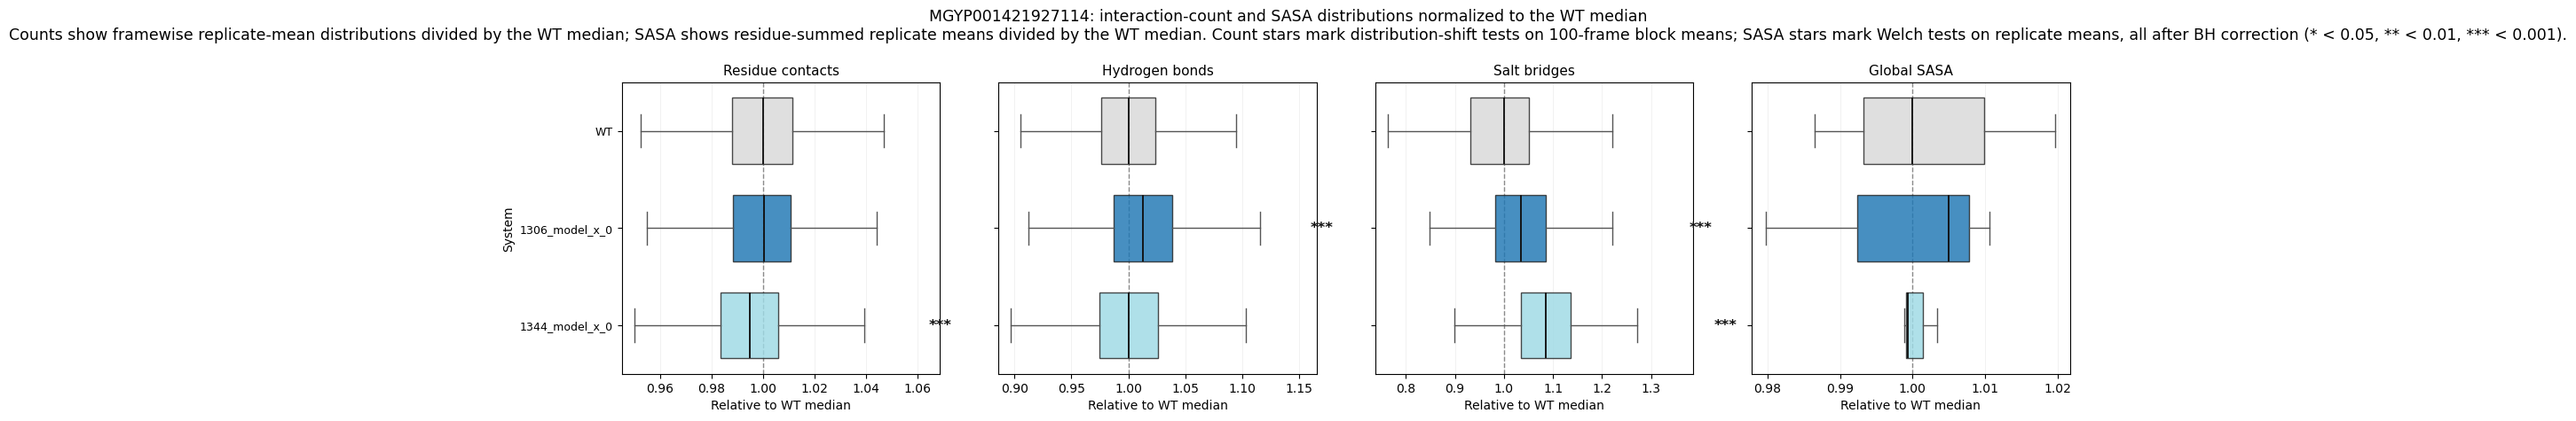

,family,system,short_label,wildtype_system,metric_key,metric_label,test_name,n_variant_samples,n_wildtype_samples,variant_mean,wildtype_mean,mean_difference,test_statistic,p_value,p_value_fdr,significant_fdr,stars,direction_vs_wt
0,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,337_New_17444_0,A0A2S1LEZ1,global_sasa,Global SASA,welch_ttest,3,3,14734.375233,14516.432677,217.942556,1.581118,0.190272,0.194327,False,,higher
1,A0A2S1LEZ1,A0A2S1LEZ1_344_New_17444_0,344_New_17444_0,A0A2S1LEZ1,global_sasa,Global SASA,welch_ttest,3,3,15026.603920,14516.432677,510.171244,3.304793,0.034141,0.040970,True,*,higher
2,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,362_New_17444_0,A0A2S1LEZ1,global_sasa,Global SASA,welch_ttest,3,3,14812.539797,14516.432677,296.107120,1.636712,0.194327,0.194327,False,,higher
3,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,337_New_17444_0,A0A2S1LEZ1,hbond_counts,Hydrogen bonds,block_permutation_ks,450,450,158.056956,161.262733,-3.205778,0.322222,0.000500,0.000666,True,***,lower
4,A0A2S1LEZ1,A0A2S1LEZ1_344_New_17444_0,344_New_17444_0,A0A2S1LEZ1,hbond_counts,Hydrogen bonds,block_permutation_ks,450,450,156.508822,161.262733,-4.753911,0.413333,0.000500,0.000666,True,***,lower
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,MGYP001421927114,MGYP001421927114_1344_model_x_0,1344_model_x_0,MGYP001421927114,hbond_counts,Hydrogen bonds,block_permutation_ks,450,450,155.272200,155.439978,-0.167778,0.082222,0.096452,0.154323,False,,lower
72,MGYP001421927114,MGYP001421927114_1306_model_x_0,1306_model_x_0,MGYP001421927114,residue_contacts,Residue contacts,block_permutation_ks,450,450,844.828133,845.148067,-0.319933,0.048889,0.645177,0.860237,False,,lower
73,MGYP001421927114,MGYP001421927114_1344_model_x_0,1344_model_x_0,MGYP001421927114,residue_contacts,Residue contacts,block_permutation_ks,450,450,841.299089,845.148067,-3.848978,0.175556,0.000500,0.001000,True,***,lower
74,MGYP001421927114,MGYP001421927114_1306_model_x_0,1306_model_x_0,MGYP001421927114,saltbridge,Salt bridges,block_permutation_ks,450,450,20.269489,19.531511,0.737978,0.206667,0.000500,0.001000,True,***,higher


In [13]:
absolute_metric_significance_tables = []

for family_id in md_variant_bundle.family_ids:
    family_significance_df = helper_fugure4.compute_md_variant_absolute_metric_significance_df(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        interaction_count_block_by_metric=md_variant_bundle.interaction_count_block_by_metric,
        interaction_count_replicate_by_metric=md_variant_bundle.interaction_count_replicate_by_metric,
        global_sasa_replicate_df=md_variant_bundle.global_sasa_replicate_df,
    )
    absolute_metric_significance_tables.append(family_significance_df)
    display(
        family_significance_df[
            [
                'family', 'short_label', 'metric_label', 'variant_mean', 'wildtype_mean',
                'mean_difference', 'test_name', 'n_variant_samples', 'n_wildtype_samples',
                'p_value', 'p_value_fdr', 'stars', 'direction_vs_wt',
            ]
        ]
    )
    figure = helper_fugure4.plot_md_family_absolute_metric_boxplots(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        interaction_count_summary_by_metric=md_variant_bundle.interaction_count_summary_by_metric,
        interaction_count_block_by_metric=md_variant_bundle.interaction_count_block_by_metric,
        interaction_count_replicate_by_metric=md_variant_bundle.interaction_count_replicate_by_metric,
        global_sasa_replicate_df=md_variant_bundle.global_sasa_replicate_df,
        significance_df=family_significance_df,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'interaction_boxplots' / f'{family_id}_absolute_metric_boxplots.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)

absolute_metric_significance_df = pd.concat(absolute_metric_significance_tables, ignore_index=True)
absolute_metric_significance_df.to_csv(
    GLOBAL_MD_VARIANT_SUMMARY_DIR / 'all_variants_absolute_metric_significance_vs_wt.csv',
    index=False,
)
display(absolute_metric_significance_df)


### Occupancy heatmaps for contacts, salt bridges, and H-bonds

How to read these panels:

- **Rows** are residue-residue interaction pairs.
- **Columns** are WT plus all variants in one family.
- **Color** is the mean occupancy of that pair across replicates, on a 0 to 1 scale.
- The row set is not all possible pairs. It is limited to the **top WT-divergent pairs**, ranked by the **largest absolute occupancy shift to WT across variants in the family**.

This is a practical ranking for interpretation, not a formal significance filter.



A0A2S1LEZ1: top WT-divergent residue-contact pairs


,interest_rank,pair_label,max_abs_delta_vs_wt,mean_abs_delta_vs_wt
0,1,VAL124 - LEU128,1.000000,0.750000
1,2,THR126 - LEU130,1.000000,0.500006
2,3,THR126 - TYR130,1.000000,0.500000
3,4,VAL122 - THR126,0.999956,0.749789
4,5,THR124 - TYR127,0.999933,0.749950
5,6,VAL124 - TYR127,0.999933,0.749939
6,7,PRO121 - VAL124,0.999933,0.749800
7,8,PHE152 - ILE156,0.999911,0.249978
8,9,SER119 - VAL122,0.999889,0.749894
9,10,PRO121 - THR124,0.999689,0.749767


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/interaction_heatmaps/A0A2S1LEZ1_pair_occupancy_heatmaps.png


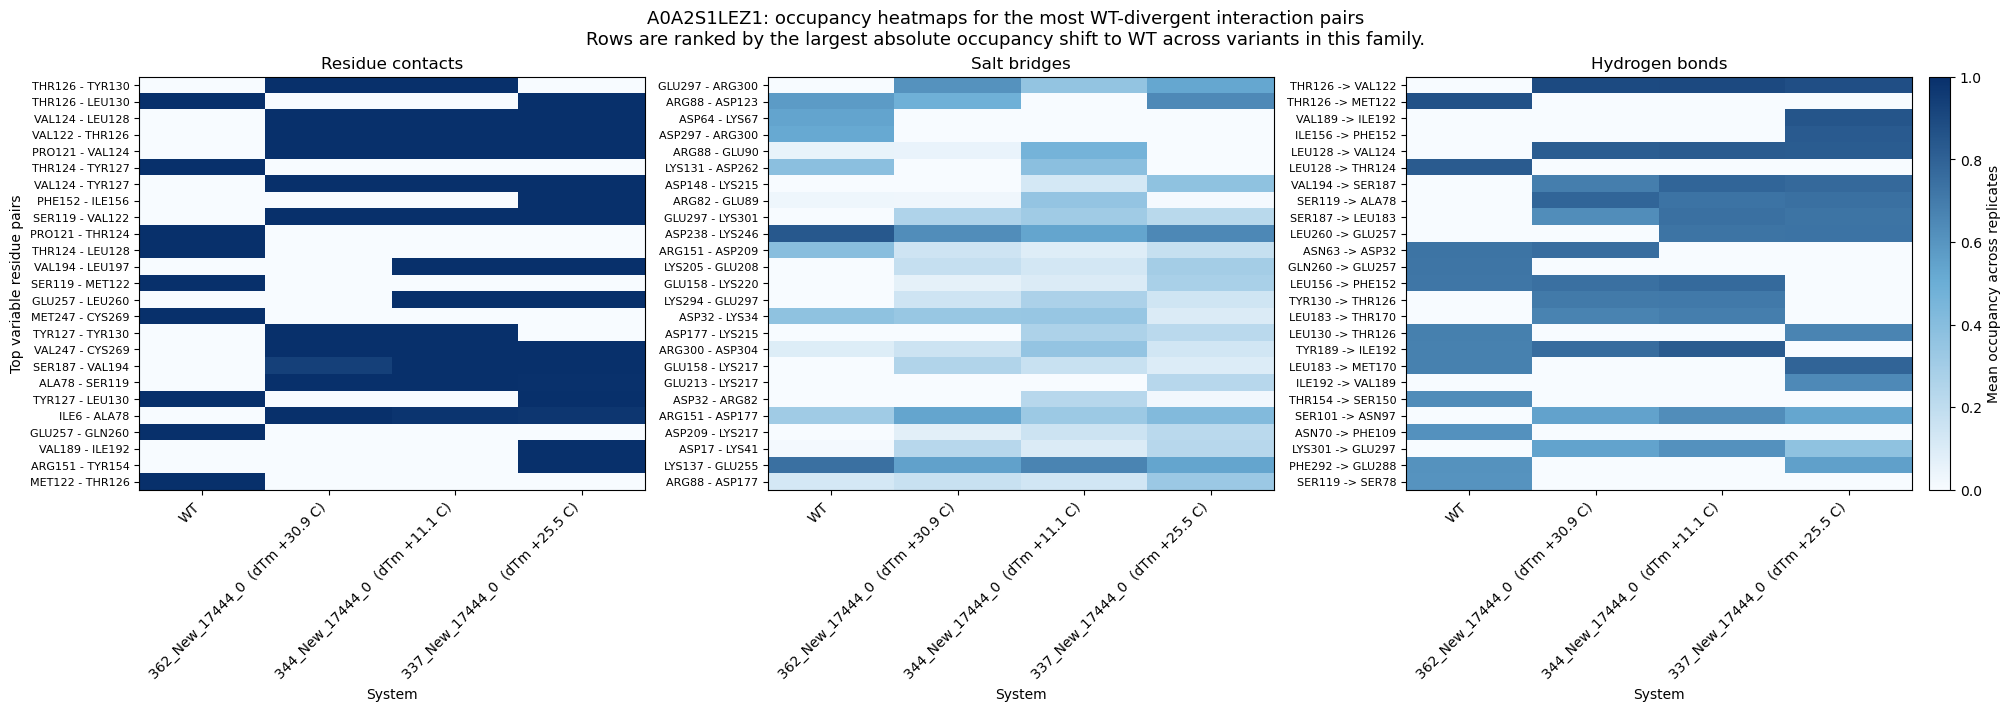


A0A372IUB3: top WT-divergent residue-contact pairs


,interest_rank,pair_label,max_abs_delta_vs_wt,mean_abs_delta_vs_wt
0,1,LYS270 - GLN278,1.0,0.800000
1,2,PHE253 - TYR264,1.0,0.800000
2,3,TYR253 - TYR264,1.0,0.799892
3,4,ARG137 - TYR253,1.0,0.799778
4,5,CYS269 - LYS278,1.0,0.733200
5,6,THR285 - LYS289,1.0,0.466351
6,7,LYS270 - LYS278,1.0,0.399991
7,8,PRO136 - ARG139,1.0,0.399990
8,9,LYS270 - GLU277,1.0,0.333344
9,10,VAL270 - LYS278,1.0,0.333329


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/interaction_heatmaps/A0A372IUB3_pair_occupancy_heatmaps.png


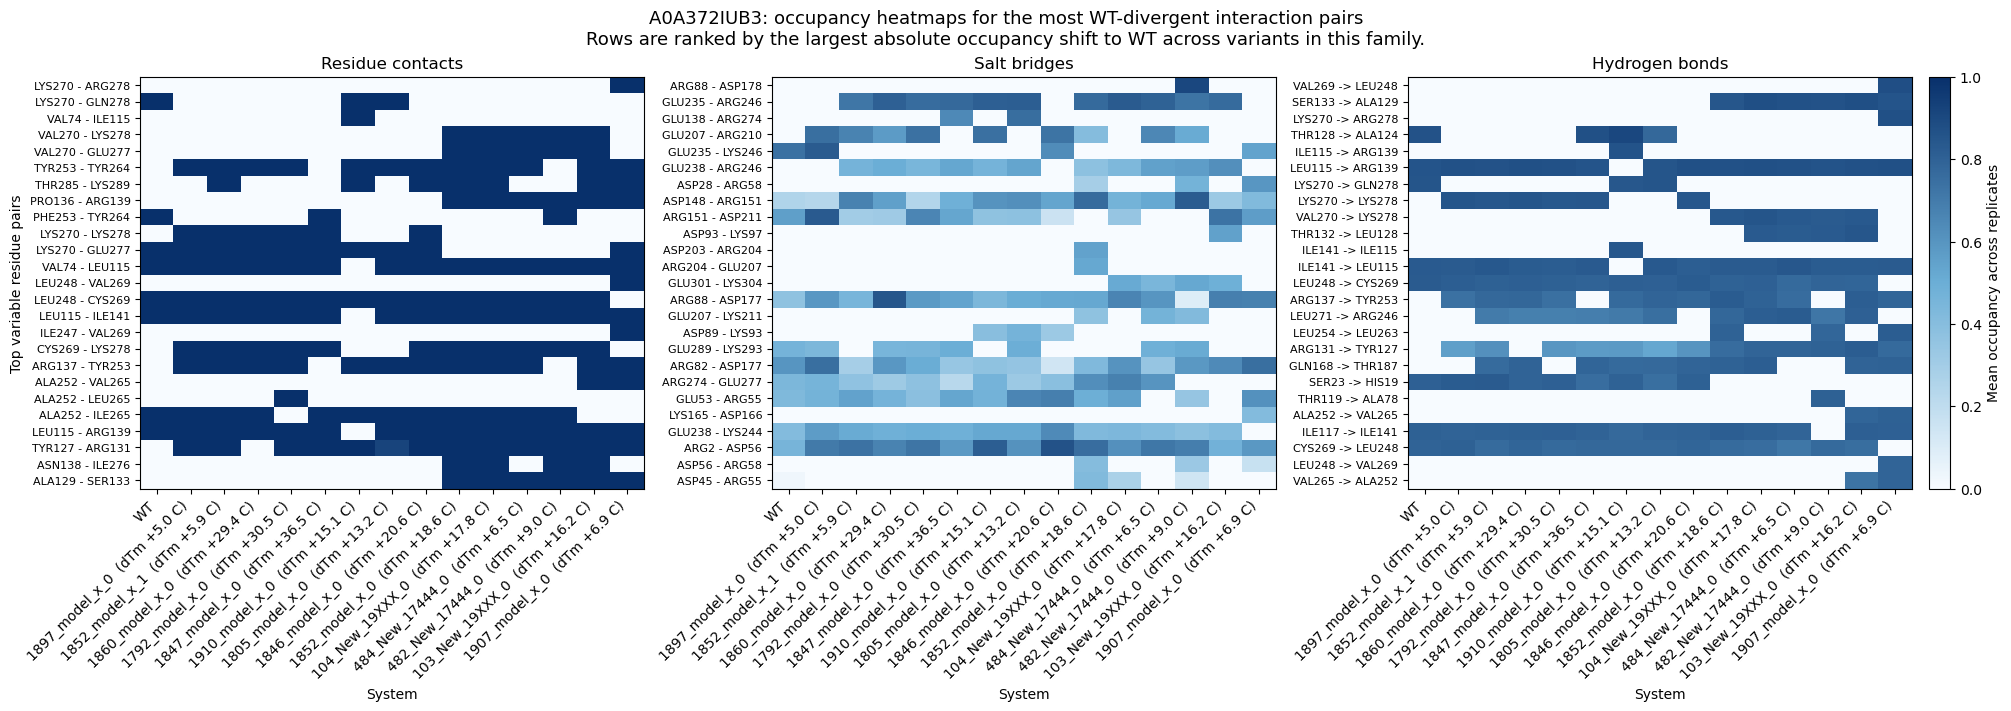


MGYP001421927114: top WT-divergent residue-contact pairs


,interest_rank,pair_label,max_abs_delta_vs_wt,mean_abs_delta_vs_wt
0,1,ALA258 - ALA271,1.000000,0.666667
1,2,ALA258 - VAL271,0.999978,0.666119
2,3,LEU130 - SER134,0.999956,0.666444
3,4,LEU130 - CYS134,0.999911,0.666607
4,5,ALA257 - ALA271,0.999800,0.666533
5,6,ARG131 - GLU135,0.999756,0.666504
6,7,ARG131 - SER134,0.999711,0.663667
7,8,ARG131 - GLY135,0.999711,0.664585
8,9,PHE171 - MET183,0.999533,0.666356
9,10,GLY106 - TYR110,0.999444,0.662919


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/interaction_heatmaps/MGYP001421927114_pair_occupancy_heatmaps.png


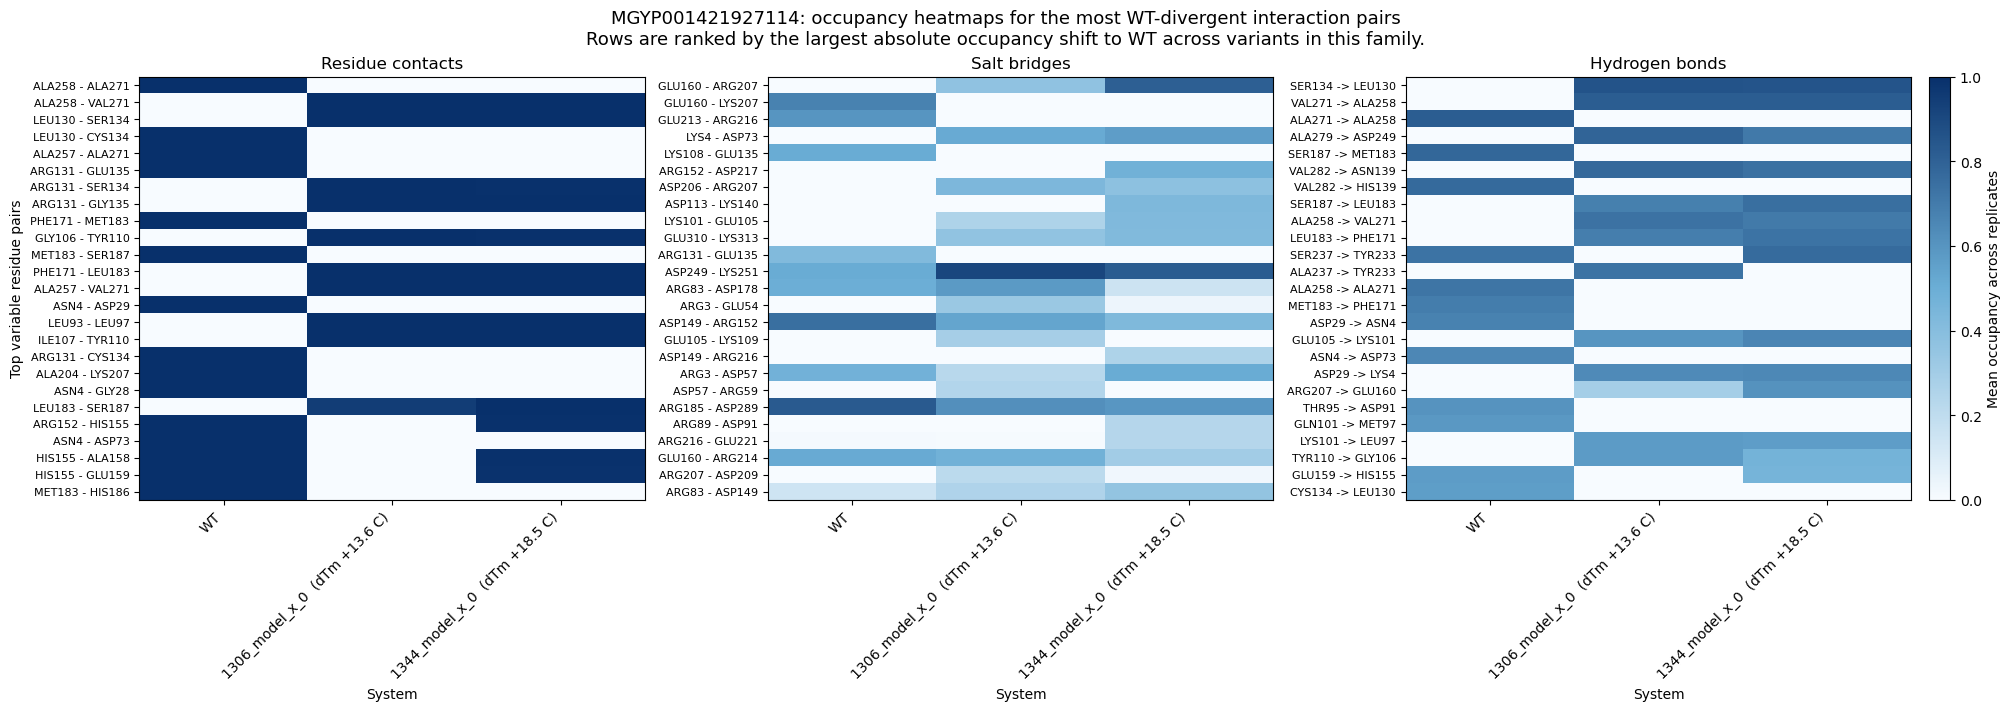

In [14]:
for family_id in md_variant_bundle.family_ids:
    print()
    print(f'{family_id}: top WT-divergent residue-contact pairs')
    display(
        md_family_pair_interest_tables[family_id]['residue_contact_pairs'][
            ['interest_rank', 'pair_label', 'max_abs_delta_vs_wt', 'mean_abs_delta_vs_wt']
        ].head(10)
    )
    figure = plot_md_family_pair_heatmaps(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        pair_summary_by_metric=md_variant_bundle.pair_summary_by_metric,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'interaction_heatmaps' / f'{family_id}_pair_occupancy_heatmaps.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Per-variant gained and lost interaction bars

How to read these panels:

- **Bars to the right of zero**: occupancy gained relative to WT.
- **Bars to the left of zero**: occupancy lost relative to WT.
- **Black outlines**: pairs that touch the local mutation neighborhood.
- Each panel shows the most extreme gained and lost pairs for one variant.

The notebook saves these plots for every variant but only previews the top-ranked variant from each family inline to keep the notebook readable.


A0A2S1LEZ1: previewing A0A2S1LEZ1_337_New_17444_0


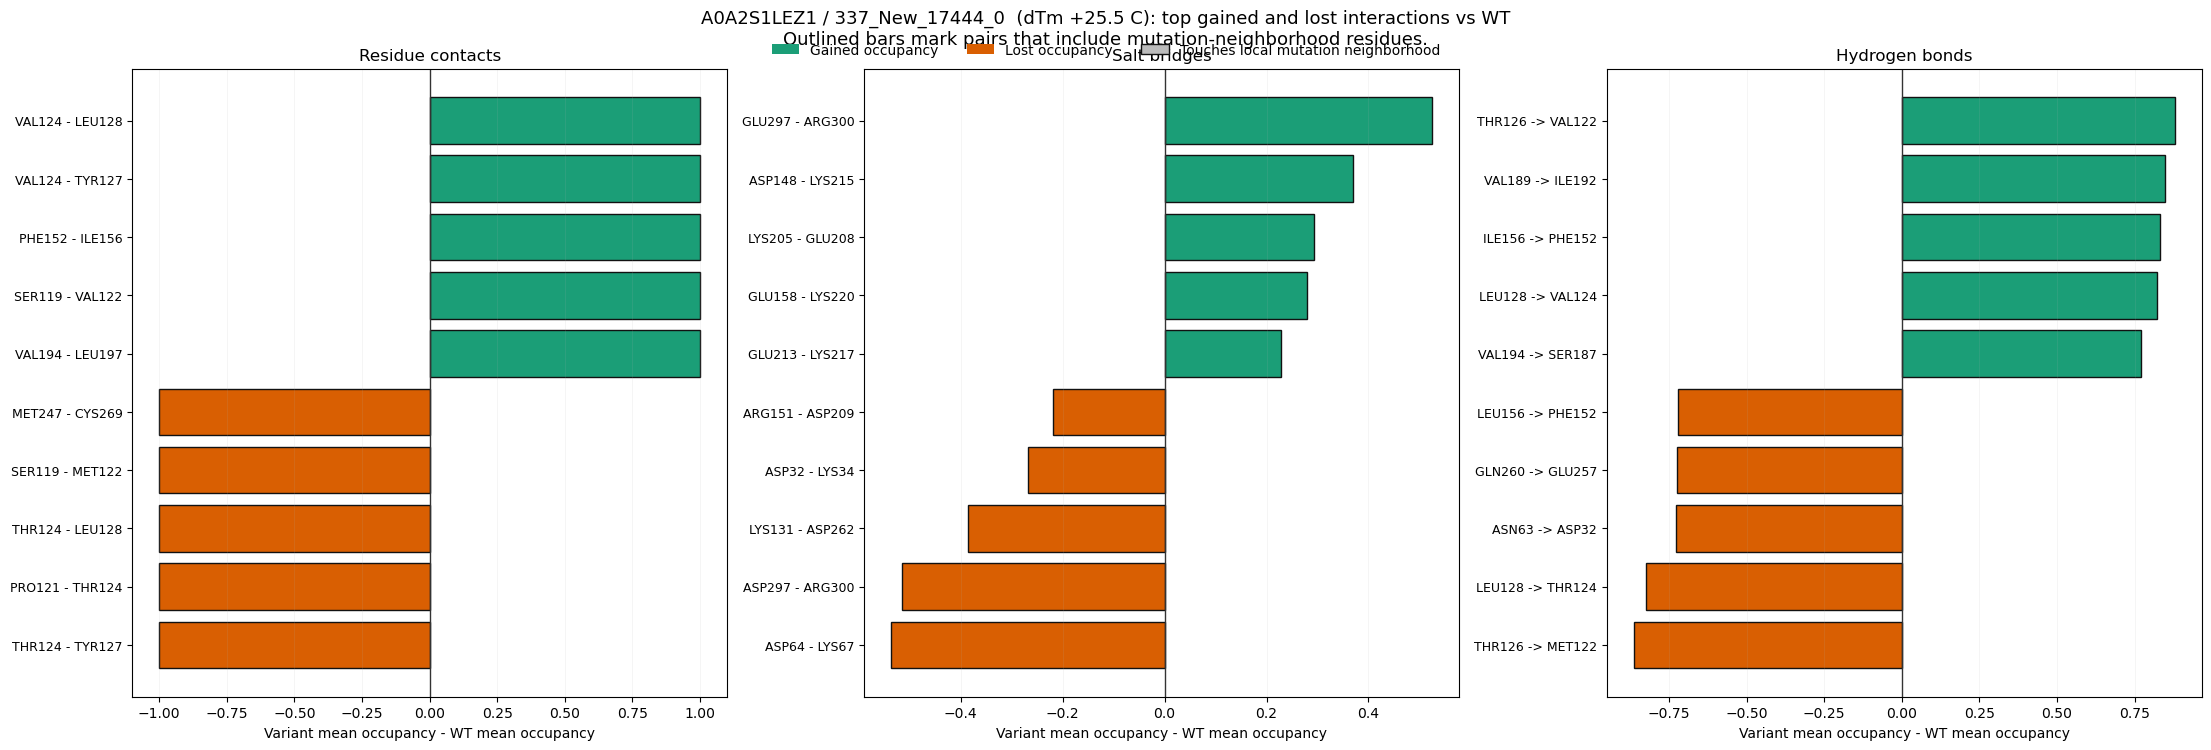

A0A372IUB3: previewing A0A372IUB3_482_New_17444_0


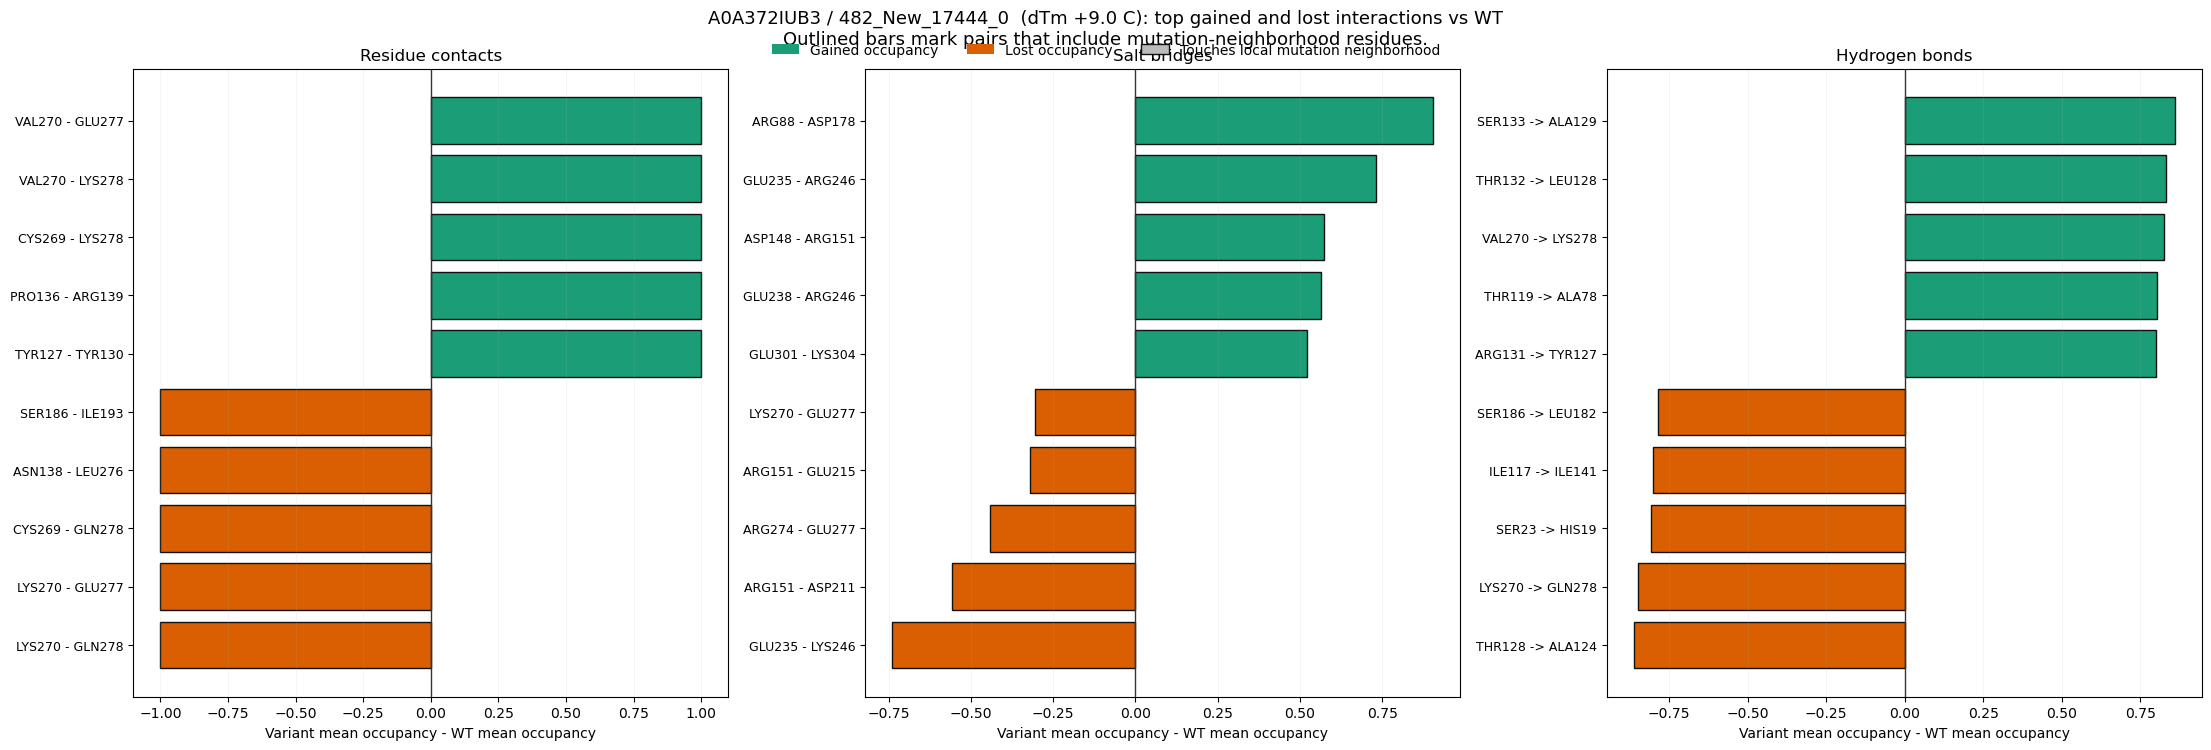

MGYP001421927114: previewing MGYP001421927114_1344_model_x_0


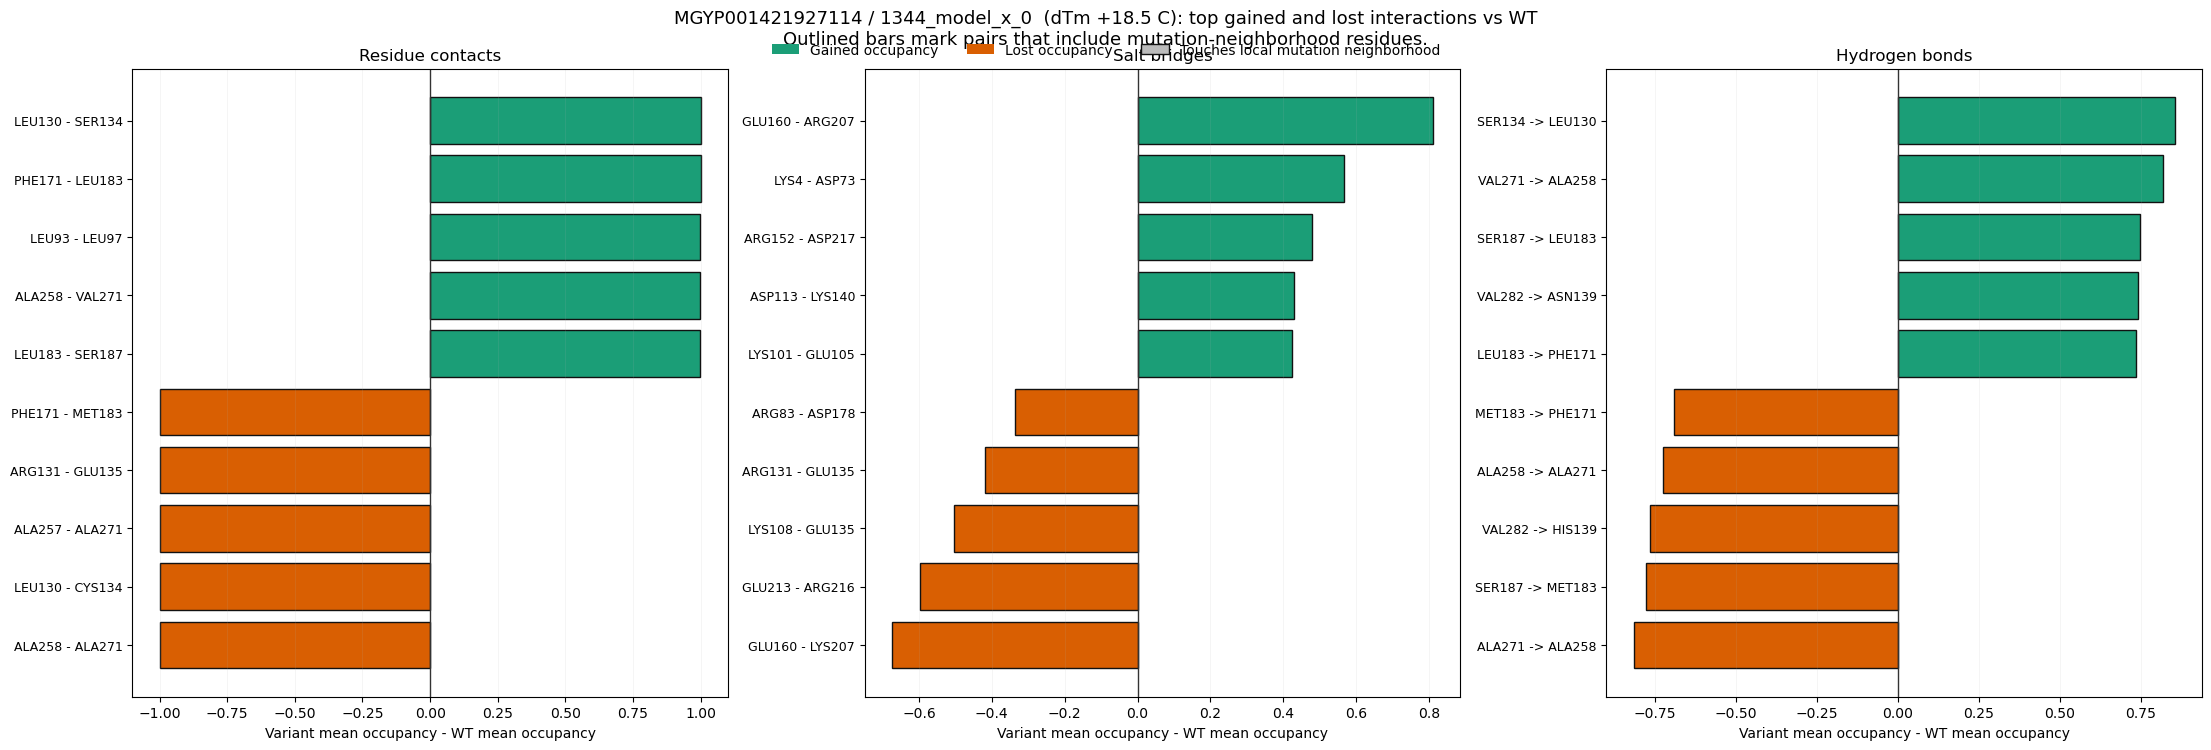

In [15]:
top_variant_by_family = (
    md_variant_bundle.variant_signal_df
    .sort_values(['family', 'family_rank', 'global_rank'])
    .groupby('family', as_index=False)
    .first()
)
preview_variant_lookup = {
    row['family']: row['variant_system']
    for _, row in top_variant_by_family.iterrows()
}

for family_id in md_variant_bundle.family_ids:
    preview_variant = preview_variant_lookup.get(family_id)
    for variant_system in compute_md_variant_order(md_variant_bundle.metadata_df, family_id):
        figure = plot_md_variant_pair_delta_bars(
            family_id=family_id,
            variant_system=variant_system,
            metadata_df=md_variant_bundle.metadata_df,
            pair_delta_by_metric=md_variant_bundle.pair_delta_by_metric,
        )
        if SAVE_MD_VARIANT_PLOTS:
            output_path = MD_VARIANT_PLOT_DIR / 'top_pair_deltas' / family_id / f'{variant_system}_top_pair_deltas.png'
            save_md_variant_figure(figure, output_path)
        if variant_system == preview_variant:
            print(f'{family_id}: previewing {variant_system}')
            plt.show()
        plt.close(figure)


### Local mutation-neighborhood summary

These heatmaps collapse the WT-vs-variant comparisons down to the mutation neighborhood.

- Each row is a variant.
- Each column is a local summary metric, such as neighborhood RMSF delta or local contact gain.
- The colors are **within-family z-scores**, so the heatmap emphasizes which variants are relatively stronger or weaker within the same WT family.

This is useful for checking whether stabilizing signatures are concentrated around mutation sites rather than being fully global.


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/neighborhood/A0A2S1LEZ1_local_neighborhood_summary.png


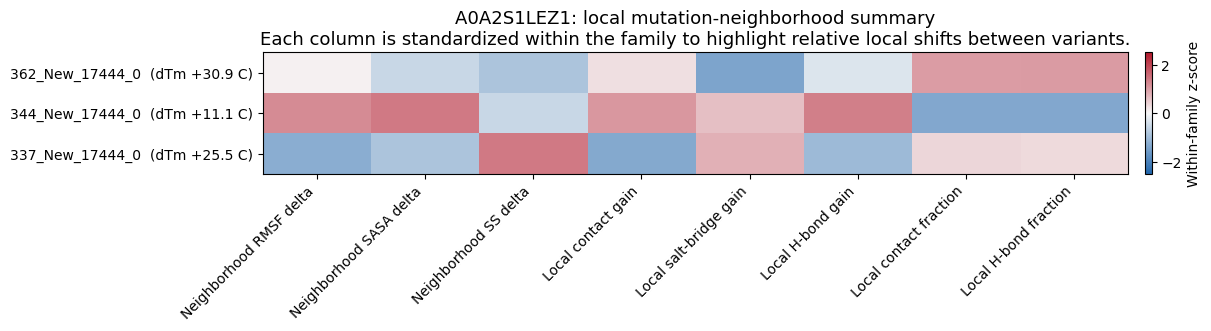

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/neighborhood/A0A372IUB3_local_neighborhood_summary.png


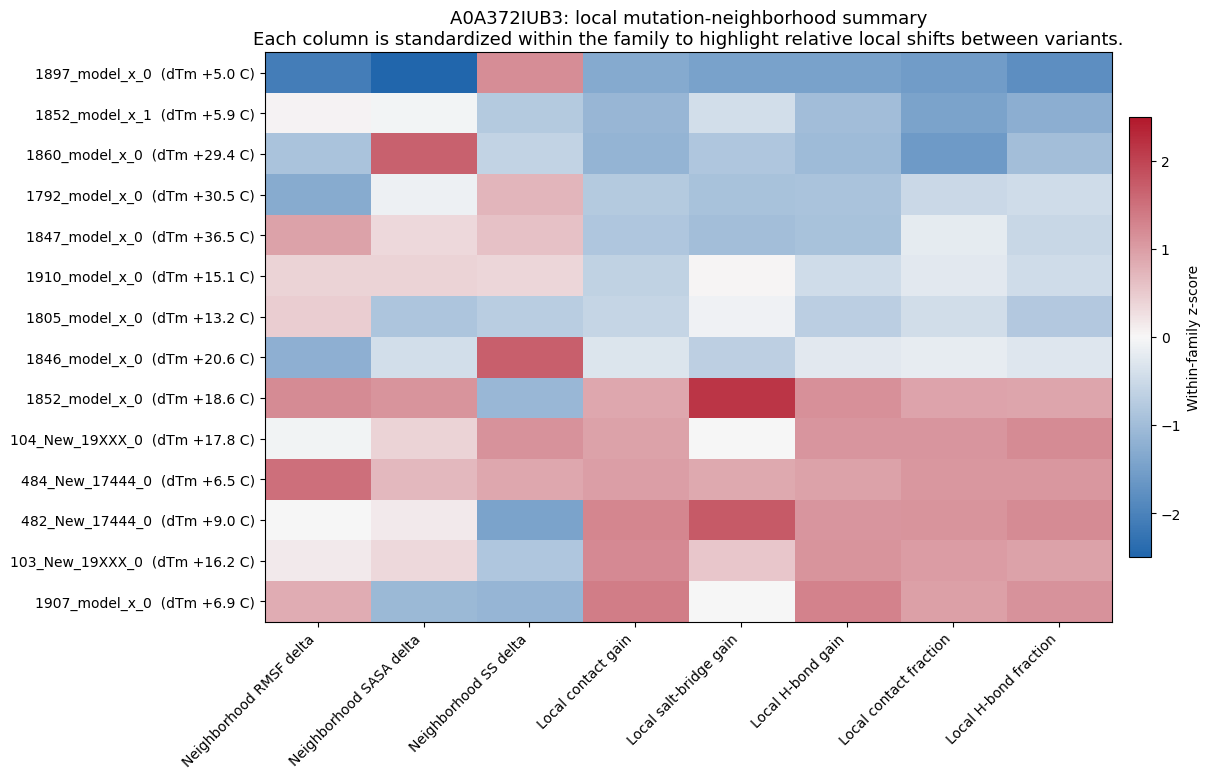

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/neighborhood/MGYP001421927114_local_neighborhood_summary.png


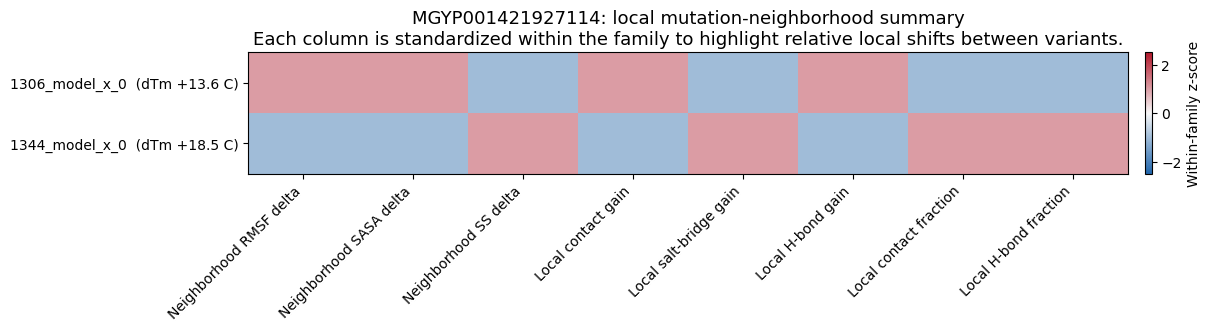

In [16]:
for family_id in md_variant_bundle.family_ids:
    figure = plot_md_family_local_signal_heatmap(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        variant_signal_df=md_variant_bundle.variant_signal_df,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'neighborhood' / f'{family_id}_local_neighborhood_summary.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Secondary-structure retention

How to read these plots:

- **Stacked bars**: global mean helix, strand, and loop fractions for each WT or variant system.
- **Helix heatmap**: per-residue helix occupancy change in the variant relative to WT.
- **Strand heatmap**: per-residue strand occupancy change in the variant relative to WT.

Positive values mean that the variant preserves that ordered state more often than WT at that residue.


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/secondary_structure/A0A2S1LEZ1_secondary_structure_summary.png


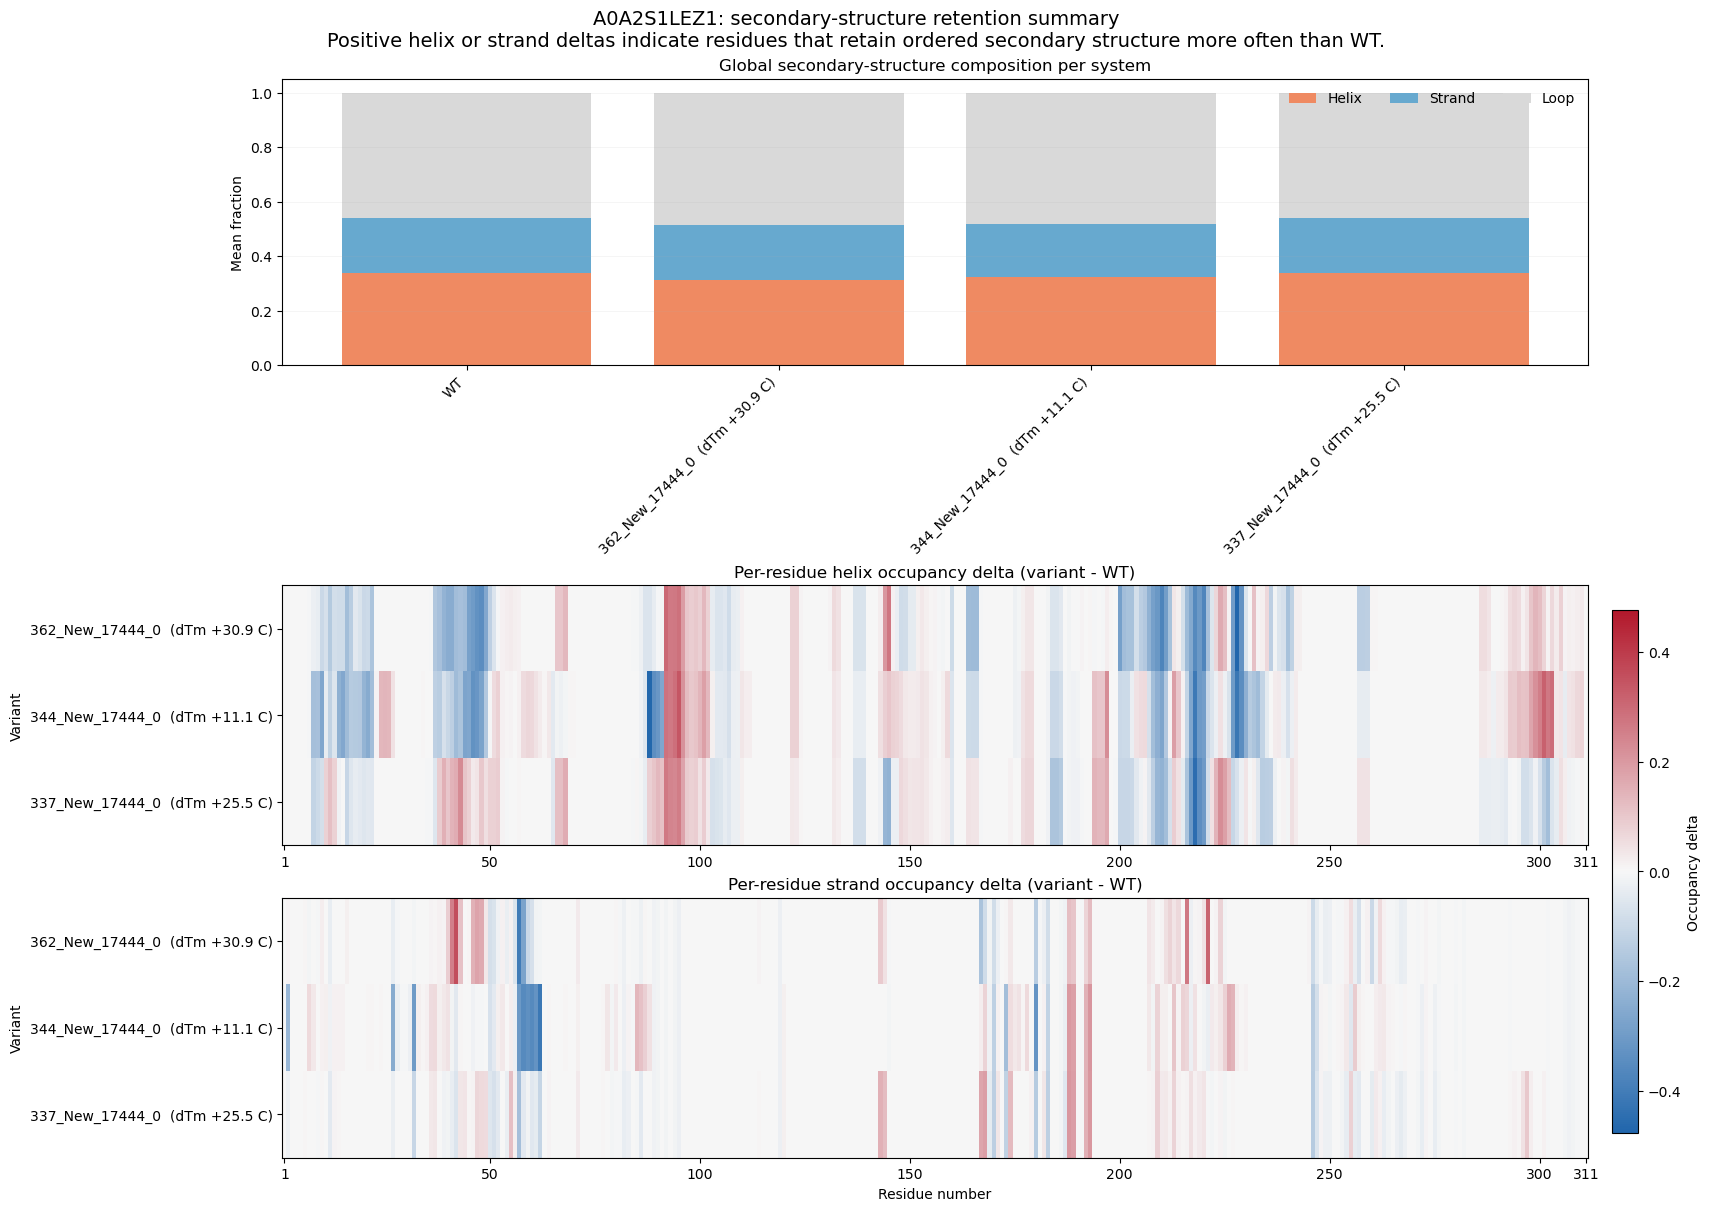

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/secondary_structure/A0A372IUB3_secondary_structure_summary.png


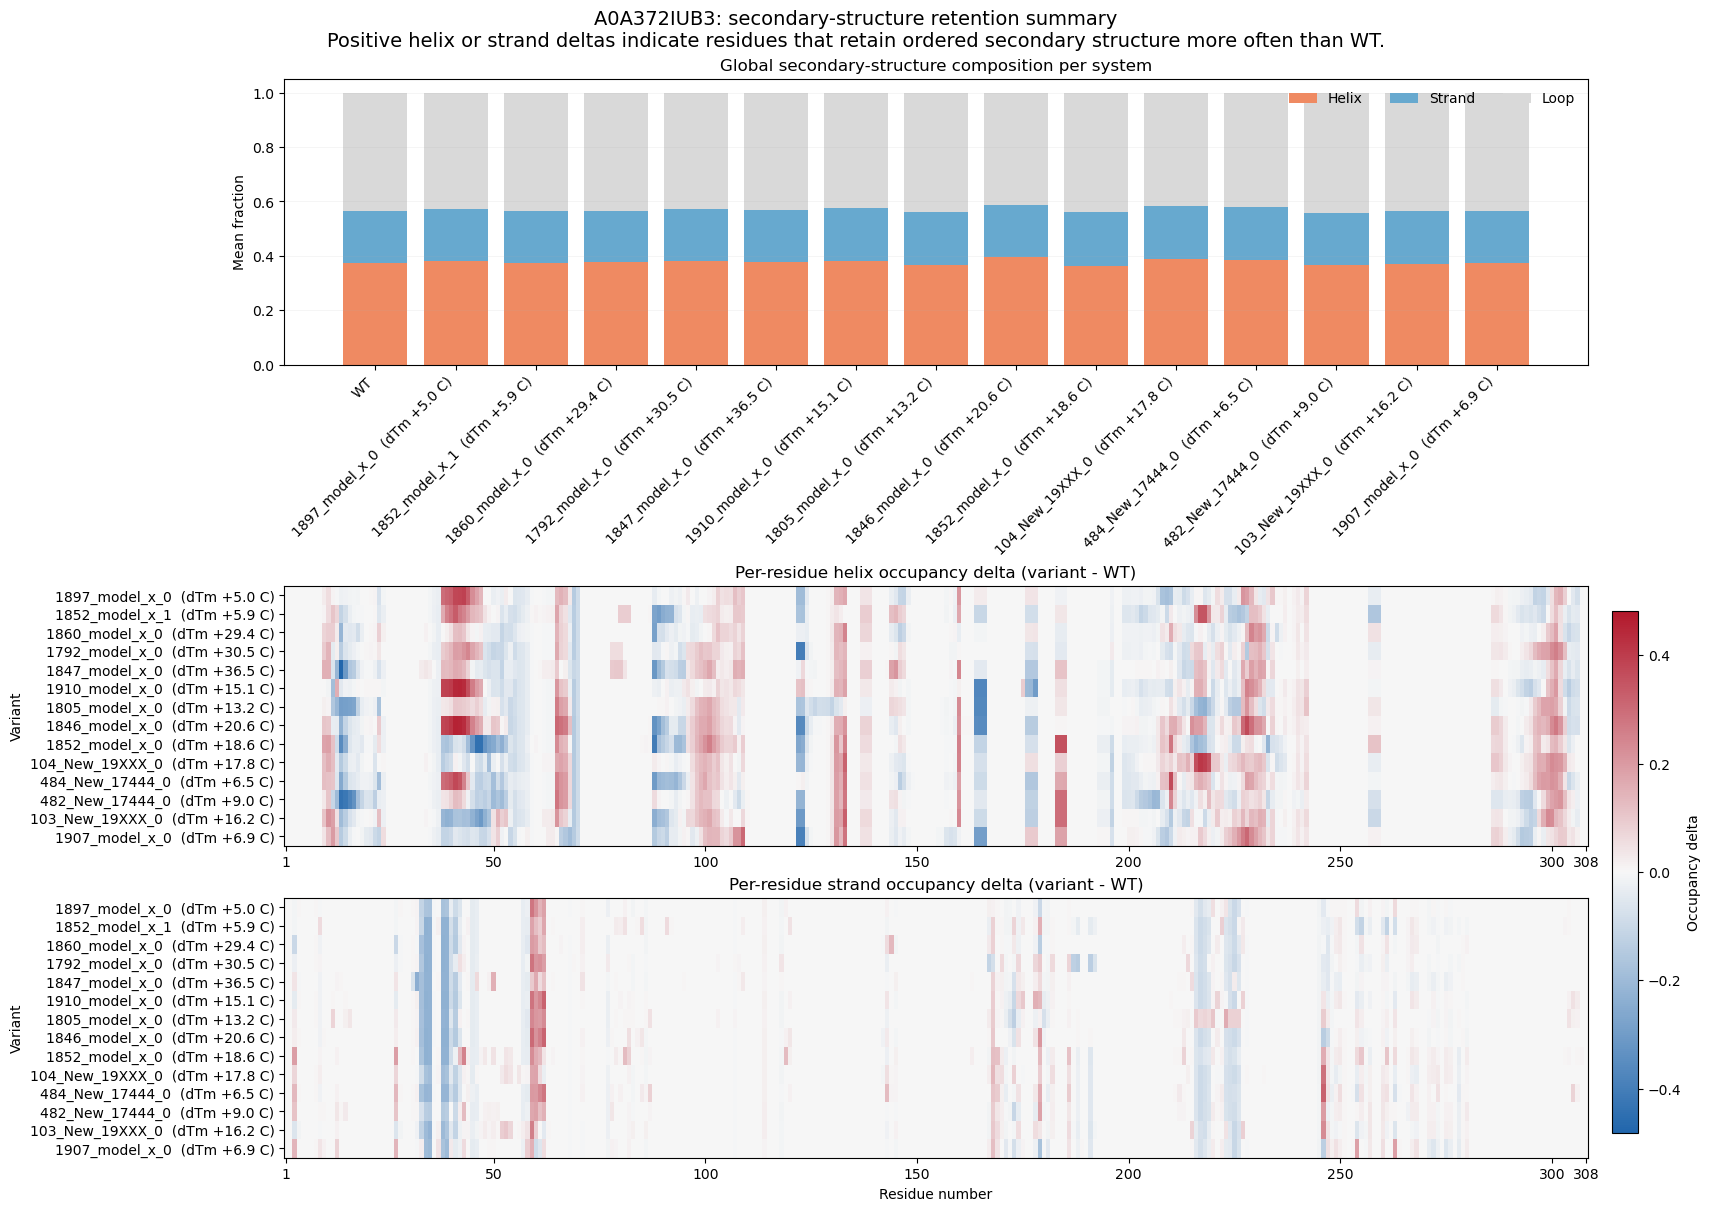

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/secondary_structure/MGYP001421927114_secondary_structure_summary.png


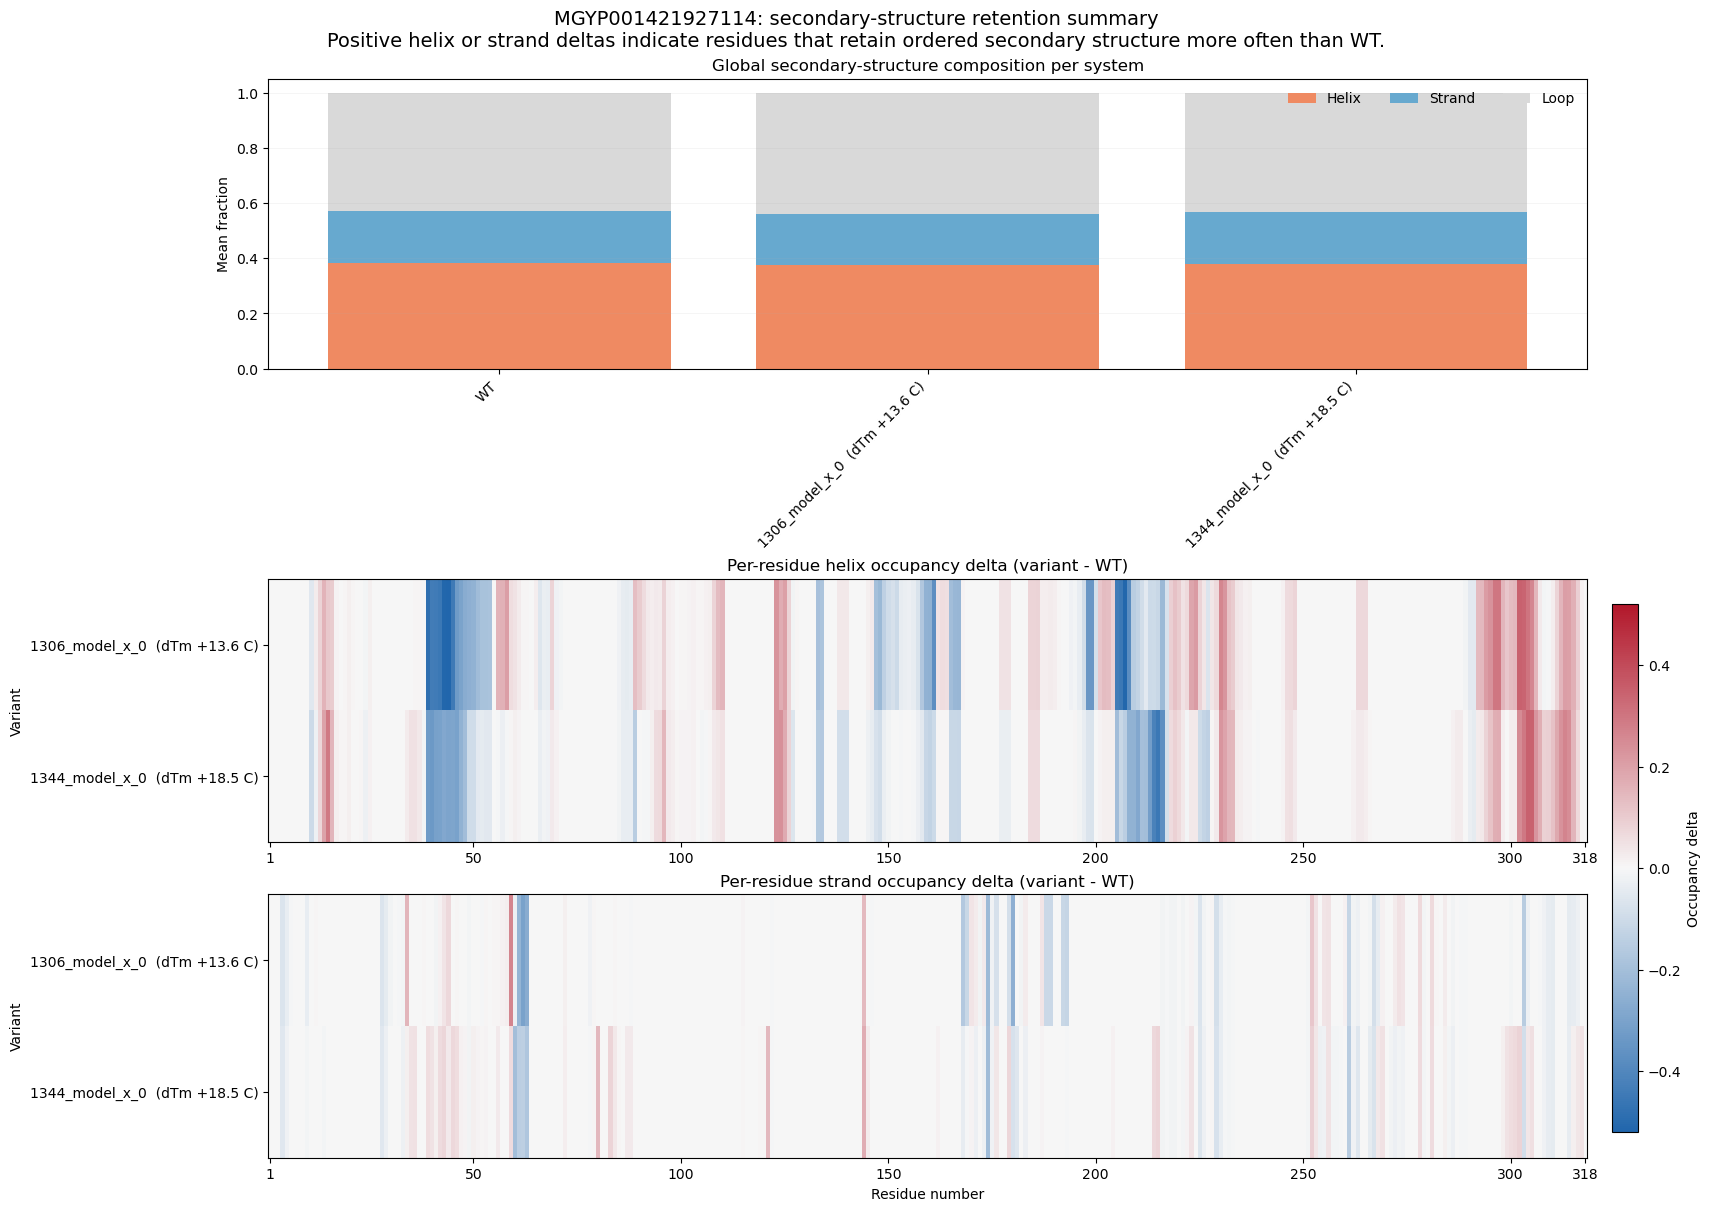

In [17]:
for family_id in md_variant_bundle.family_ids:
    figure = plot_md_family_secondary_structure_summary(
        family_id=family_id,
        metadata_df=md_variant_bundle.metadata_df,
        ss_counts_summary_df=md_variant_bundle.ss_counts_summary_df,
        ss_residue_delta_df=md_variant_bundle.ss_residue_delta_df,
    )
    if SAVE_MD_VARIANT_PLOTS:
        output_path = MD_VARIANT_PLOT_DIR / 'secondary_structure' / f'{family_id}_secondary_structure_summary.png'
        save_md_variant_figure(figure, output_path)
        print(output_path)
    plt.show()
    plt.close(figure)


### Summary dashboard and shared patterns

The dashboard ranks variants by a simple composite score built from six WT-relative signals:

1. lower RMSF in the mutation neighborhood,
2. increased residue-contact occupancy,
3. increased salt-bridge occupancy,
4. increased H-bond occupancy,
5. lower SASA in the mutation neighborhood,
6. higher ordered secondary-structure retention in the mutation neighborhood.

Each signal is converted to a percentile-style rank and the composite score is the mean of those ranks. This is a **heuristic prioritization score**, not a trained predictor of melting temperature.


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/dashboard/variant_signal_dashboard.png


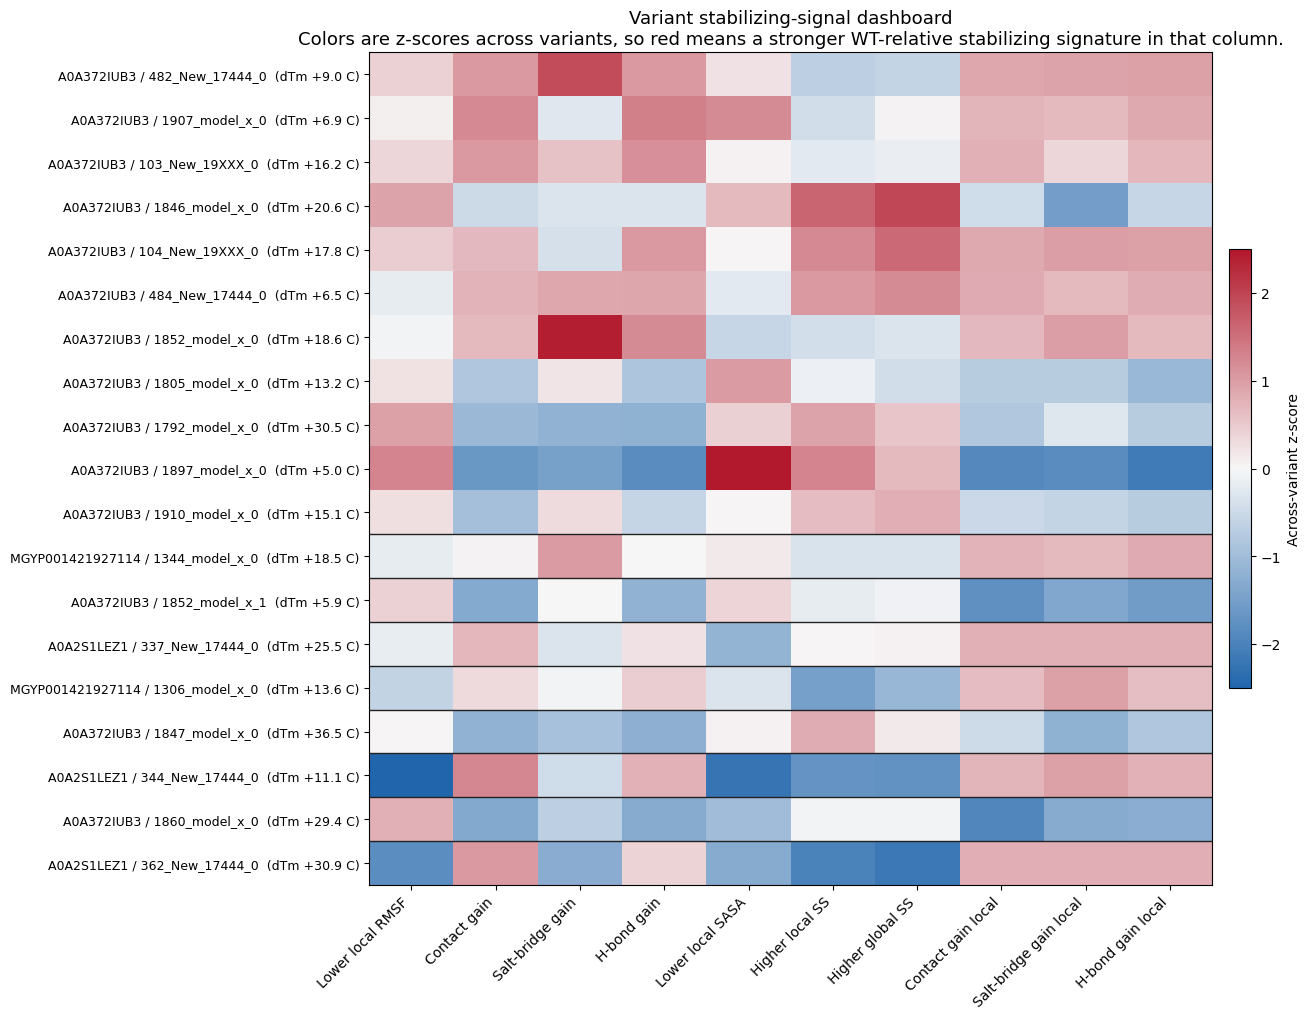

/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/sandra/MD_SIM/Round_3_additional_metric_csvs/0_300000/plots/dashboard/family_shared_pattern_heatmap.png


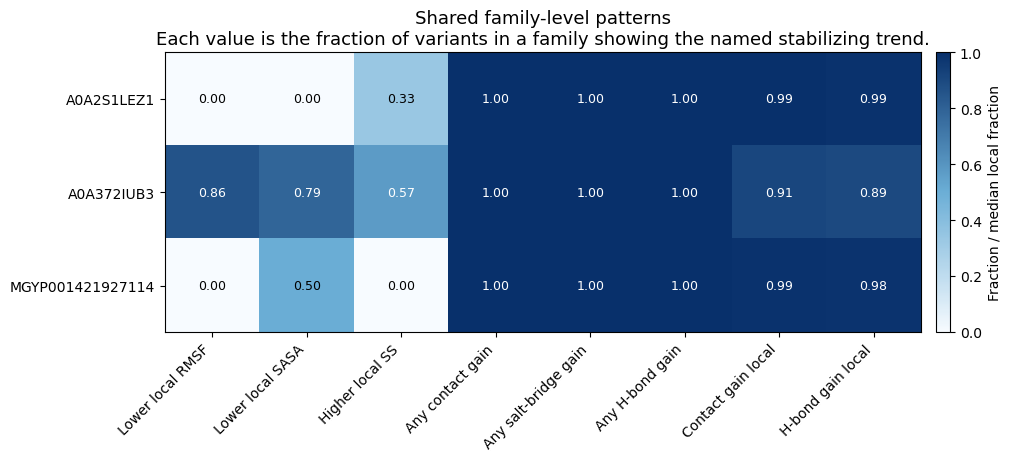

,global_rank,family,family_rank,variant_label,median_tm_celsius,delta_tm_to_wildtype_celsius,composite_stabilizing_score,delta_rmsf_neighborhood_mean,contact_gain_total,saltbridge_gain_total,hbond_gain_total,delta_sasa_neighborhood_mean,delta_ordered_ss_neighborhood_mean,delta_ordered_fraction_global
0,1.0,A0A372IUB3,1.0,482_New_17444_0 (dTm +9.0 C),64.8800,8.9680,0.710526,-0.108296,262.135244,9.208333,51.147089,-0.222394,-0.006756,-0.007220
1,2.0,A0A372IUB3,2.0,1907_model_x_0 (dTm +6.9 C),62.8599,6.9479,0.692982,-0.016317,272.114178,6.291600,54.074467,-0.925649,-0.003983,-0.000205
2,3.0,A0A372IUB3,3.0,103_New_19XXX_0 (dTm +16.2 C),72.1360,16.2240,0.684211,-0.093256,261.778822,7.446733,52.115156,-0.101713,-0.001281,-0.002305
3,4.0,A0A372IUB3,4.0,1846_model_x_0 (dTm +20.6 C),76.5092,20.5972,0.675439,-0.251089,175.305911,6.215156,37.526000,-0.545397,0.020977,0.020827
4,5.0,A0A372IUB3,5.0,104_New_19XXX_0 (dTm +17.8 C),73.7585,17.8465,0.657895,-0.119325,241.994733,6.146222,51.116978,-0.074149,0.016041,0.016445
5,6.0,A0A372IUB3,6.0,484_New_17444_0 (dTm +6.5 C),62.3620,6.4500,0.622807,0.062746,245.522933,7.846867,49.756756,0.103861,0.013997,0.012519
6,7.0,A0A372IUB3,7.0,1852_model_x_0 (dTm +18.6 C),74.5336,18.6216,0.578947,0.027723,240.801333,9.894378,52.765378,0.345380,-0.003690,-0.004391
7,8.0,A0A372IUB3,8.0,1805_model_x_0 (dTm +13.2 C),69.0969,13.1849,0.552632,-0.056817,157.173444,6.925422,32.305822,-0.797733,-0.000275,-0.005473
8,9.0,A0A372IUB3,9.0,1792_model_x_0 (dTm +30.5 C),86.3846,30.4726,0.526316,-0.260208,143.845089,5.059978,28.839156,-0.371391,0.012460,0.005424
9,10.0,A0A372IUB3,10.0,1897_model_x_0 (dTm +5.0 C),60.9217,5.0097,0.517544,-0.348229,112.343244,4.652022,22.687956,-1.837497,0.016611,0.006603


,family,n_variants,fraction_lower_local_rmsf,fraction_lower_local_sasa,fraction_higher_local_ss,fraction_contact_gain,fraction_saltbridge_gain,fraction_hbond_gain,median_composite_score,median_contact_local_fraction,median_hbond_local_fraction
0,A0A2S1LEZ1,3,0.000000,0.000000,0.333333,1.0,1.0,1.0,0.368421,0.993618,0.988001
1,A0A372IUB3,14,0.857143,0.785714,0.571429,1.0,1.0,1.0,0.565789,0.909336,0.894989
2,MGYP001421927114,2,0.000000,0.500000,0.000000,1.0,1.0,1.0,0.456140,0.987628,0.984069
3,ALL,19,0.631579,0.631579,0.473684,1.0,1.0,1.0,0.517544,0.987438,0.979731


In [18]:
dashboard_figure = plot_md_variant_signal_dashboard(md_variant_bundle.variant_signal_df)
if SAVE_MD_VARIANT_PLOTS:
    output_path = MD_VARIANT_PLOT_DIR / 'dashboard' / 'variant_signal_dashboard.png'
    save_md_variant_figure(dashboard_figure, output_path)
    print(output_path)
plt.show()
plt.close(dashboard_figure)

family_pattern_figure = plot_md_variant_family_pattern_heatmap(md_variant_bundle.family_pattern_summary_df)
if SAVE_MD_VARIANT_PLOTS:
    output_path = MD_VARIANT_PLOT_DIR / 'dashboard' / 'family_shared_pattern_heatmap.png'
    save_md_variant_figure(family_pattern_figure, output_path)
    print(output_path)
plt.show()
plt.close(family_pattern_figure)

display(
    md_variant_bundle.variant_signal_df[
        [
            'global_rank', 'family', 'family_rank', 'variant_label',
            'median_tm_celsius', 'delta_tm_to_wildtype_celsius',
            'composite_stabilizing_score', 'delta_rmsf_neighborhood_mean',
            'contact_gain_total', 'saltbridge_gain_total', 'hbond_gain_total',
            'delta_sasa_neighborhood_mean', 'delta_ordered_ss_neighborhood_mean',
            'delta_ordered_fraction_global',
        ]
    ]
)
display(md_variant_bundle.family_pattern_summary_df)
